In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Primary (full ablations):

Pair: SAM2 + nnU-Net (heterogeneous; your main claim)

Dataset: Cross-domain (ACDC) and In-domain (M&Ms)

Run: DST vs averaging, fallback ON/OFF

Why: Establish the mechanism works and is robust, both in and out of domain.

Secondary (light ablations):

Pair: MedSAM2 + nnU-Net (strong+strong)

Dataset: In-domain

Run: DST vs averaging + fallback ON/OFF

Why: Show trends replicate for a stronger foundation model without duplicating everything.

Tertiary (sanity check only):

Pair: SAM2 + UNet++ (suboptimal+suboptimal)

Dataset: One domain (your choice)

Run: DST vs averaging

Why: Verify DST helps even with weaker models; skip the rest.

SAM2+nnunet - no DST, no Fallback - in domain

no calibration


=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===
LV: Dice = 0.9407 ± 0.0348 | IoU = 0.8900 ± 0.0591
RV: Dice = 0.8680 ± 0.0480 | IoU = 0.7699 ± 0.0716
MYO: Dice = 0.9077 ± 0.0554 | IoU = 0.8353 ± 0.0863
Macro Avg: Dice = 0.9055 ± 0.0312 | IoU = 0.8317 ± 0.0488

Visualizing Case: 003_SA_ED, Slice: 5


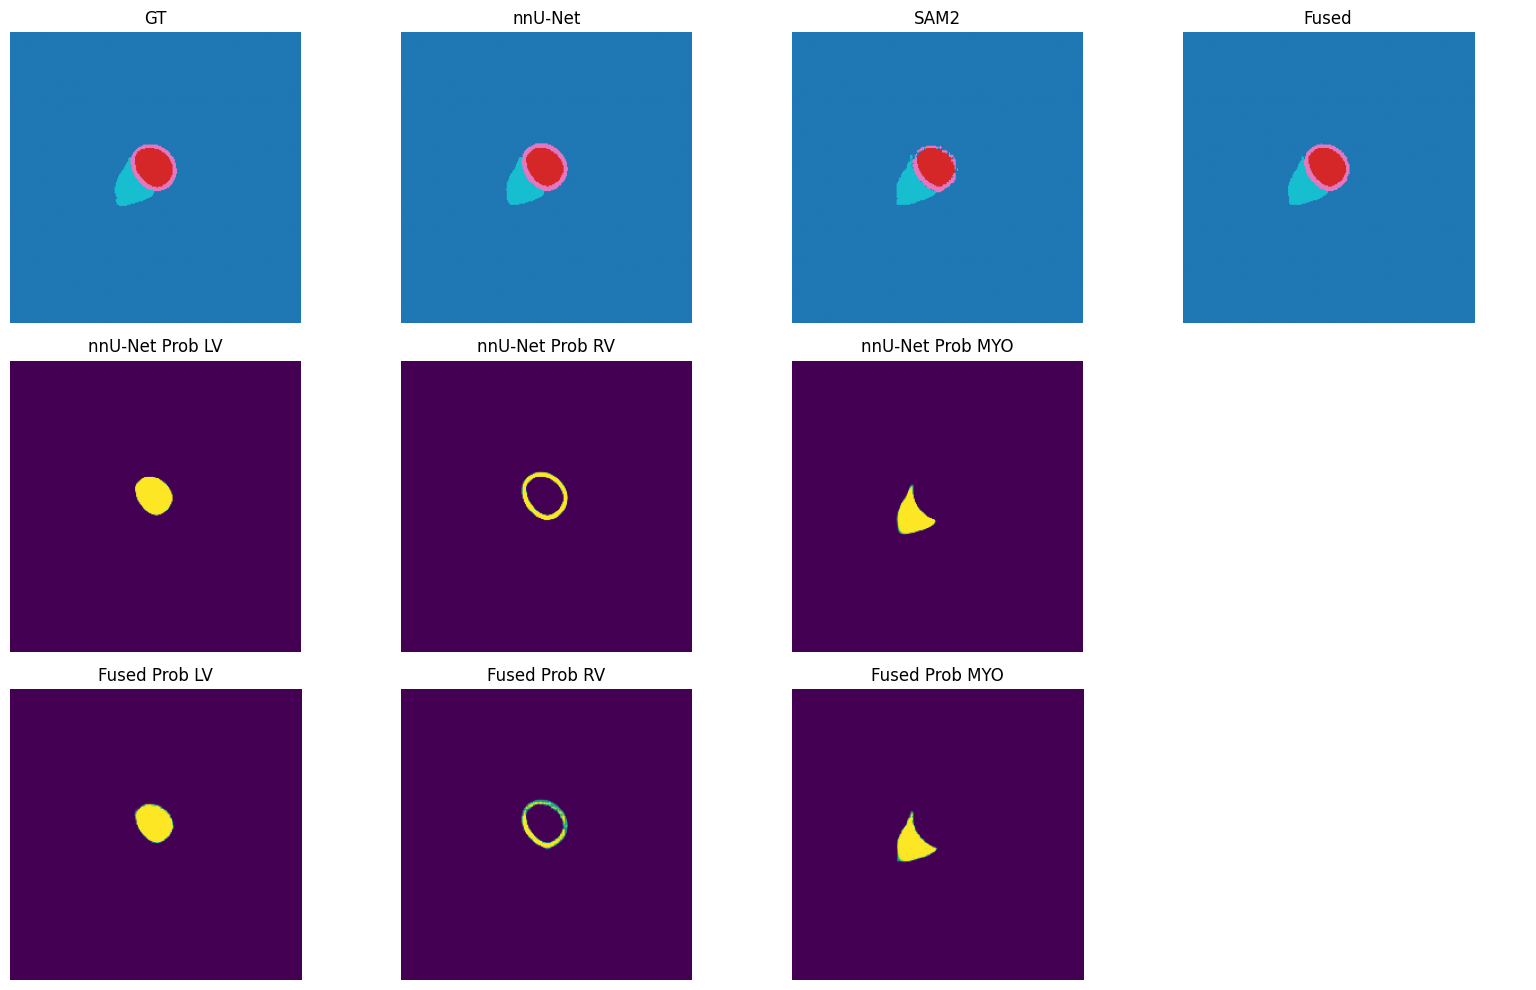

In [ ]:
# --- SIMPLE AVERAGING FUSION + VISUALIZATION (nnU-Net + SAM2, UNCALIBRATED) ---
import os
import numpy as np
import nibabel as nib
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
nnunet_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output2"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

# ---------------- FUSION ----------------
all_cases = [f.replace("_0000.nii.gz", "") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()

dice_all, iou_all = [], []
case_for_vis = all_cases[0]  # visualize first case (can change)
slice_for_vis = 5            # slice index to visualize

for case_id in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{case_id}.npz")
    sam2_path = os.path.join(sam2_dir, f"{case_id}_sam2_soft.npz")
    label_path = os.path.join(label_dir, f"{case_id}.nii.gz")

    if not (os.path.exists(nn_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C,H,W,D)
    sam2   = np.load(sam2_path)["probabilities"]
    label  = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)

    _, H, W, D = nnunet.shape
    fused_vol = np.zeros((H, W, D), dtype=np.uint8)

    for z in range(D):
        nn_slice  = np.moveaxis(nnunet[:, :, :, z], 0, -1)
        sam_soft  = np.moveaxis(sam2[:, :, :, z], 0, -1)
        sam_resized = cv2.resize(sam_soft, (W, H), interpolation=cv2.INTER_LINEAR)
        bg = 1.0 - np.clip(np.sum(sam_resized, axis=-1, keepdims=True), 0, 1)
        sam_full = np.concatenate([bg, sam_resized], axis=-1)

        fused_probs = 0.5 * (sam_full + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

        # Save visualization data for chosen slice
        if case_id == case_for_vis and z == slice_for_vis:
            nn_vis = nn_slice.copy()
            sam_vis = sam_full.copy()
            fused_vis = fused_probs.copy()
            gt_vis = label[..., z].copy()
            nn_pred = np.argmax(nn_slice, axis=-1)
            sam_pred = np.argmax(sam_full, axis=-1)
            fused_pred = np.argmax(fused_probs, axis=-1)

    d, j = compute_metrics(fused_vol, label)
    dice_all.append(d.tolist() + [np.mean(d)])
    iou_all.append(j.tolist() + [np.mean(j)])

# ---------------- AGGREGATE RESULTS ----------------
dice_all, iou_all = np.array(dice_all), np.array(iou_all)
mean_dice, std_dice = np.mean(dice_all, 0), np.std(dice_all, 0)
mean_iou,  std_iou  = np.mean(iou_all,  0), np.std(iou_all,  0)

labels = ["LV", "RV", "MYO", "Macro Avg"]
print("\n=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===")
for i, lab in enumerate(labels):
    print(f"{lab}: Dice = {mean_dice[i]:.4f} ± {std_dice[i]:.4f} | IoU = {mean_iou[i]:.4f} ± {std_iou[i]:.4f}")

# ---------------- VISUALIZATION ----------------
print(f"\nVisualizing Case: {case_for_vis}, Slice: {slice_for_vis}")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Top row: masks
mask_panels = [("GT", gt_vis), ("nnU-Net", nn_pred), ("SAM2", sam_pred), ("Fused", fused_pred)]
for i, (title, img) in enumerate(mask_panels):
    axes[0, i].imshow(img, cmap="tab10", vmin=0, vmax=3)
    axes[0, i].set_title(title)
    axes[0, i].axis("off")

# Next rows: probability maps (LV, RV, MYO)
classes = ["LV", "RV", "MYO"]
for i, cls in enumerate([1, 2, 3]):
    axes[1, i].imshow(nn_vis[..., cls], cmap="viridis")
    axes[1, i].set_title(f"nnU-Net Prob {classes[i]}")
    axes[1, i].axis("off")

    axes[2, i].imshow(fused_vis[..., cls], cmap="viridis")
    axes[2, i].set_title(f"Fused Prob {classes[i]}")
    axes[2, i].axis("off")

# Hide unused subplot if any
axes[1, 3].axis("off")
axes[2, 3].axis("off")

plt.tight_layout()
plt.show()


Number of changed pixels in slice 10: 284
(102,105) nnU-Net=0, SAM2=3, Fused=0, GT=0
 nnU-Net probs: [1. 0. 0. 0.]
 SAM2 probs   : [1. 0. 0. 0.]
 Fused probs  : [1. 0. 0. 0.]

(102,106) nnU-Net=0, SAM2=3, Fused=3, GT=0
 nnU-Net probs: [1. 0. 0. 0.]
 SAM2 probs   : [1. 0. 0. 0.]
 Fused probs  : [1. 0. 0. 0.]

(102,112) nnU-Net=3, SAM2=0, Fused=0, GT=3
 nnU-Net probs: [1. 0. 0. 0.]
 SAM2 probs   : [1. 0. 0. 0.]
 Fused probs  : [1. 0. 0. 0.]

(103,112) nnU-Net=3, SAM2=0, Fused=3, GT=3
 nnU-Net probs: [1. 0. 0. 0.]
 SAM2 probs   : [1. 0. 0. 0.]
 Fused probs  : [1. 0. 0. 0.]

(103,114) nnU-Net=3, SAM2=0, Fused=0, GT=3
 nnU-Net probs: [1. 0. 0. 0.]
 SAM2 probs   : [1. 0. 0. 0.]
 Fused probs  : [1. 0. 0. 0.]


=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===
LV: Dice = 0.9407 ± 0.0348 | IoU = 0.8900 ± 0.0591
RV: Dice = 0.8680 ± 0.0480 | IoU = 0.7699 ± 0.0716
MYO: Dice = 0.9077 ± 0.0554 | IoU = 0.8353 ± 0.0863
Macro Avg: Dice = 0.9055 ± 0.0312 | IoU = 0.8317 ± 0.0488

Inspecting pi

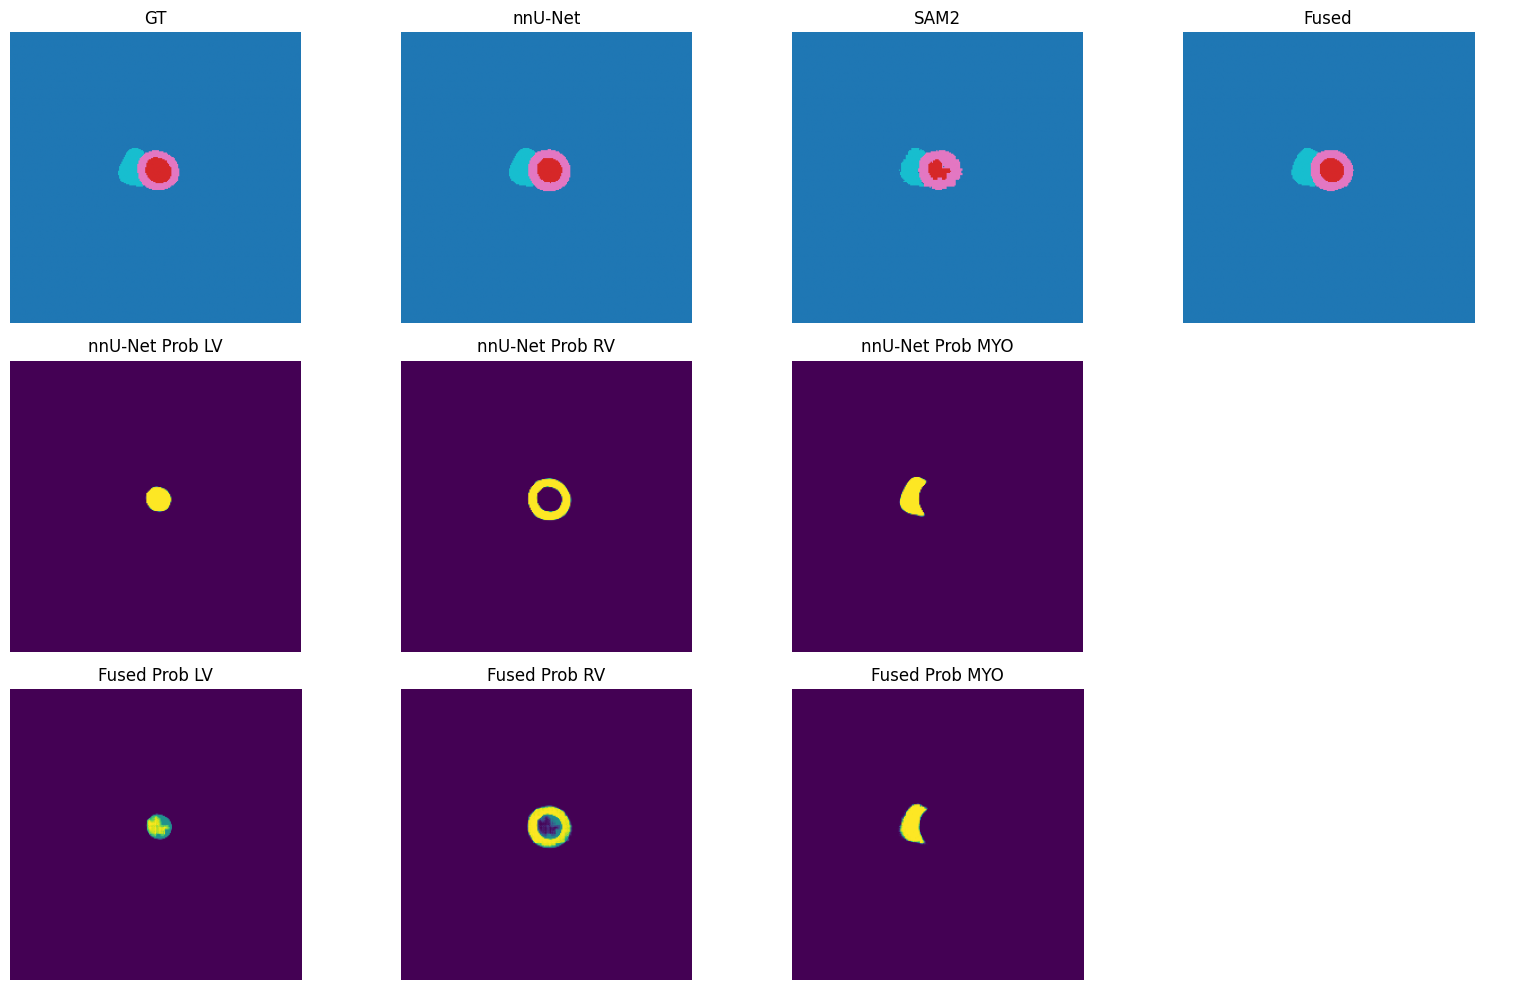

In [ ]:


dice_all, iou_all = [], []
case_for_vis = all_cases[9]  # visualize first case (can change)
slice_for_vis = 5            # slice index to visualize

for case_id in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{case_id}.npz")
    sam2_path = os.path.join(sam2_dir, f"{case_id}_sam2_soft.npz")
    label_path = os.path.join(label_dir, f"{case_id}.nii.gz")

    if not (os.path.exists(nn_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C,H,W,D)
    sam2   = np.load(sam2_path)["probabilities"]
    label  = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)

    _, H, W, D = nnunet.shape
    fused_vol = np.zeros((H, W, D), dtype=np.uint8)

    for z in range(D):
        nn_slice  = np.moveaxis(nnunet[:, :, :, z], 0, -1)
        sam_soft  = np.moveaxis(sam2[:, :, :, z], 0, -1)
        sam_resized = cv2.resize(sam_soft, (W, H), interpolation=cv2.INTER_LINEAR)
        bg = 1.0 - np.clip(np.sum(sam_resized, axis=-1, keepdims=True), 0, 1)
        sam_full = np.concatenate([bg, sam_resized], axis=-1)

        fused_probs = 0.5 * (sam_full + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

        # Save visualization data for chosen slice
        if case_id == case_for_vis and z == slice_for_vis:
            nn_vis = nn_slice.copy()
            sam_vis = sam_full.copy()
            fused_vis = fused_probs.copy()
            gt_vis = label[..., z].copy()
            nn_pred = np.argmax(nn_slice, axis=-1)
            sam_pred = np.argmax(sam_full, axis=-1)
            fused_pred = np.argmax(fused_probs, axis=-1)

    d, j = compute_metrics(fused_vol, label)
    dice_all.append(d.tolist() + [np.mean(d)])
    iou_all.append(j.tolist() + [np.mean(j)])

    diff_mask = (fused_pred != nn_pred) | (fused_pred != sam_pred)
changed_pixels = np.argwhere(diff_mask)

print(f"Number of changed pixels in slice {z}: {len(changed_pixels)}")
if len(changed_pixels) > 0:
    for idx in changed_pixels[:5]:  # show up to 5 examples
        y, x = idx
        print(f"({y},{x}) nnU-Net={nn_pred[y,x]}, SAM2={sam_pred[y,x]}, "
              f"Fused={fused_pred[y,x]}, GT={gt_vis[y,x]}")
        print(" nnU-Net probs:", np.round(nn_slice[y,x,:],3))
        print(" SAM2 probs   :", np.round(sam_full[y,x,:],3))
        print(" Fused probs  :", np.round(fused_probs[y,x,:],3))
        print()


# ---------------- AGGREGATE RESULTS ----------------
dice_all, iou_all = np.array(dice_all), np.array(iou_all)
mean_dice, std_dice = np.mean(dice_all, 0), np.std(dice_all, 0)
mean_iou,  std_iou  = np.mean(iou_all,  0), np.std(iou_all,  0)

labels = ["LV", "RV", "MYO", "Macro Avg"]
print("\n=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===")
for i, lab in enumerate(labels):
    print(f"{lab}: Dice = {mean_dice[i]:.4f} ± {std_dice[i]:.4f} | IoU = {mean_iou[i]:.4f} ± {std_iou[i]:.4f}")


# ---------------- DEBUG: PRINT SAMPLE PROBABILITIES ----------------
# Pick a pixel coordinate inside the myocardium region (or change manually)
y, x = np.unravel_index(np.argmax(gt_vis > 0), gt_vis.shape)

print(f"\nInspecting pixel (y={y}, x={x}) in case '{case_for_vis}', slice {slice_for_vis}")
print("-----------------------------------------------------------")

# Print per-class probabilities (bg, LV, RV, MYO)
print("nnU-Net probs:", np.round(nn_vis[y, x, :], 4))
print("SAM2   probs:", np.round(sam_vis[y, x, :], 4))
print("Fused  probs:", np.round(fused_vis[y, x, :], 4))

# Also show which class each model predicted
print("\nPredicted class (argmax):")
print(f"  nnU-Net → {np.argmax(nn_vis[y, x, :])}")
print(f"  SAM2    → {np.argmax(sam_vis[y, x, :])}")
print(f"  Fused   → {np.argmax(fused_vis[y, x, :])}")
print(f"  GT      → {gt_vis[y, x]}")


# ---------------- VISUALIZATION ----------------
print(f"\nVisualizing Case: {case_for_vis}, Slice: {slice_for_vis}")
fig, axes = plt.subplots(3, 4, figsize=(16, 10))

# Top row: masks
mask_panels = [("GT", gt_vis), ("nnU-Net", nn_pred), ("SAM2", sam_pred), ("Fused", fused_pred)]
for i, (title, img) in enumerate(mask_panels):
    axes[0, i].imshow(img, cmap="tab10", vmin=0, vmax=3)
    axes[0, i].set_title(title)
    axes[0, i].axis("off")

# Next rows: probability maps (LV, RV, MYO)
classes = ["LV", "RV", "MYO"]
for i, cls in enumerate([1, 2, 3]):
    axes[1, i].imshow(nn_vis[..., cls], cmap="viridis")
    axes[1, i].set_title(f"nnU-Net Prob {classes[i]}")
    axes[1, i].axis("off")

    axes[2, i].imshow(fused_vis[..., cls], cmap="viridis")
    axes[2, i].set_title(f"Fused Prob {classes[i]}")
    axes[2, i].axis("off")

# Hide unused subplot if any
axes[1, 3].axis("off")
axes[2, 3].axis("off")

plt.tight_layout()
plt.show()


In [ ]:
dice_all, iou_all = [], []
case_for_vis = all_cases[9]  # visualize 10th case (change as needed)
slice_for_vis = 5            # slice index to visualize
changed_pixels = None        # prepare variable for later

for case_id in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{case_id}.npz")
    sam2_path = os.path.join(sam2_dir, f"{case_id}_sam2_soft.npz")
    label_path = os.path.join(label_dir, f"{case_id}.nii.gz")

    if not (os.path.exists(nn_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C,H,W,D)
    sam2   = np.load(sam2_path)["probabilities"]
    label  = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)

    _, H, W, D = nnunet.shape
    fused_vol = np.zeros((H, W, D), dtype=np.uint8)

    for z in range(D):
        nn_slice  = np.moveaxis(nnunet[:, :, :, z], 0, -1)
        sam_soft  = np.moveaxis(sam2[:, :, :, z], 0, -1)
        sam_resized = cv2.resize(sam_soft, (W, H), interpolation=cv2.INTER_LINEAR)
        bg = 1.0 - np.clip(np.sum(sam_resized, axis=-1, keepdims=True), 0, 1)
        sam_full = np.concatenate([bg, sam_resized], axis=-1)

        fused_probs = 0.5 * (sam_full + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

        # Save visualization slice
        if case_id == case_for_vis and z == slice_for_vis:
            nn_vis = nn_slice.copy()
            sam_vis = sam_full.copy()
            fused_vis = fused_probs.copy()
            gt_vis = label[..., z].copy()
            nn_pred = np.argmax(nn_slice, axis=-1)
            sam_pred = np.argmax(sam_full, axis=-1)
            fused_pred = np.argmax(fused_probs, axis=-1)

            # compute changed pixels for debug
            diff_mask = (fused_pred != nn_pred) | (fused_pred != sam_pred)
            changed_pixels = np.argwhere(diff_mask)

    d, j = compute_metrics(fused_vol, label)
    dice_all.append(d.tolist() + [np.mean(d)])
    iou_all.append(j.tolist() + [np.mean(j)])

# ---------- PRINT CHANGED PIXELS ----------
if changed_pixels is not None:
    print(f"Number of changed pixels in slice {slice_for_vis}: {len(changed_pixels)}")
    if len(changed_pixels) > 0:
        for idx in changed_pixels[:5]:  # show up to 5 examples
            y, x = idx
            print(f"({y},{x}) nnU-Net={nn_pred[y,x]}, SAM2={sam_pred[y,x]}, "
                  f"Fused={fused_pred[y,x]}, GT={gt_vis[y,x]}")
            print(" nnU-Net probs:", np.round(nn_vis[y,x,:],3))
            print(" SAM2 probs   :", np.round(sam_vis[y,x,:],3))
            print(" Fused probs  :", np.round(fused_vis[y,x,:],3))
            print()


Number of changed pixels in slice 5: 284
(102,105) nnU-Net=0, SAM2=3, Fused=0, GT=0
 nnU-Net probs: [0.996 0.    0.    0.004]
 SAM2 probs   : [0.317 0.    0.    0.683]
 Fused probs  : [0.657 0.    0.    0.343]

(102,106) nnU-Net=0, SAM2=3, Fused=3, GT=0
 nnU-Net probs: [0.66 0.   0.   0.34]
 SAM2 probs   : [0.225 0.    0.    0.775]
 Fused probs  : [0.443 0.    0.    0.557]

(102,112) nnU-Net=3, SAM2=0, Fused=0, GT=3
 nnU-Net probs: [0.167 0.    0.    0.833]
 SAM2 probs   : [0.918 0.    0.    0.082]
 Fused probs  : [0.543 0.    0.    0.457]

(103,112) nnU-Net=3, SAM2=0, Fused=3, GT=3
 nnU-Net probs: [0.001 0.    0.    0.999]
 SAM2 probs   : [0.637 0.    0.    0.363]
 Fused probs  : [0.319 0.    0.    0.681]

(103,114) nnU-Net=3, SAM2=0, Fused=0, GT=3
 nnU-Net probs: [0.313 0.    0.    0.687]
 SAM2 probs   : [0.893 0.    0.    0.107]
 Fused probs  : [0.603 0.    0.    0.397]



##run this
Sam2+nnunet (in domain)

In [ ]:
# --- SIMPLE AVERAGING FUSION (nnU-Net + SAM2, UNCALIBRATED, CSV OUTPUT) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
nnunet_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output2"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"

output_csv = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_nnunet_indomain.csv"

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou, np.mean(dice), np.mean(iou)

# ---------------- FUSION + METRIC CALCULATION ----------------
all_cases = [f.replace("_0000.nii.gz", "") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()

records = []

for case_id in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{case_id}.npz")
    sam2_path = os.path.join(sam2_dir, f"{case_id}_sam2_soft.npz")
    label_path = os.path.join(label_dir, f"{case_id}.nii.gz")

    if not (os.path.exists(nn_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    # Load data
    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C,H,W,D)
    sam2   = np.load(sam2_path)["probabilities"]
    label  = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)
    _, H, W, D = nnunet.shape

    fused_vol = np.zeros((H, W, D), dtype=np.uint8)
    unet_pred = np.zeros_like(fused_vol)
    sam_pred  = np.zeros_like(fused_vol)

    for z in range(D):
        nn_slice  = np.moveaxis(nnunet[:, :, :, z], 0, -1)
        sam_soft  = np.moveaxis(sam2[:, :, :, z], 0, -1)
        sam_resized = cv2.resize(sam_soft, (W, H), interpolation=cv2.INTER_LINEAR)
        bg = 1.0 - np.clip(np.sum(sam_resized, axis=-1, keepdims=True), 0, 1)
        sam_full = np.concatenate([bg, sam_resized], axis=-1)

        # Predictions
        unet_pred[..., z] = np.argmax(nn_slice, axis=-1)
        sam_pred[..., z]  = np.argmax(sam_full, axis=-1)

        # Simple averaging fusion
        fused_probs = 0.5 * (sam_full + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # --- Compute metrics for UNet, SAM2, and Fused ---
    d_unet, j_unet, d_unet_macro, j_unet_macro = compute_metrics(unet_pred, label)
    d_sam, j_sam, d_sam_macro, j_sam_macro     = compute_metrics(sam_pred, label)
    d_fused, j_fused, d_fused_macro, j_fused_macro = compute_metrics(fused_vol, label)

    # --- Record metrics ---
    records.append([
        case_id,
        *d_unet, *j_unet,
        *d_sam, *j_sam,
        *d_fused, *j_fused,
        d_unet_macro, j_unet_macro,
        d_sam_macro, j_sam_macro,
        d_fused_macro, j_fused_macro
    ])

# ---------------- CONVERT TO CSV ----------------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV", "unet_IoU_RV", "unet_IoU_Myo",
    "sam_Dice_LV", "sam_Dice_RV", "sam_Dice_Myo",
    "sam_IoU_LV", "sam_IoU_RV", "sam_IoU_Myo",
    "fused_Dice_LV", "fused_Dice_RV", "fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet", "Macro_IoU_UNet",
    "Macro_Dice_SAM", "Macro_IoU_SAM",
    "Macro_Dice_Fused", "Macro_IoU_Fused"
]
df = pd.DataFrame(records, columns=cols)

# --- Add summary rows ---
avg = df.mean(numeric_only=True)
std = df.std(numeric_only=True)
var = df.var(numeric_only=True)
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

# Convert to DataFrame rows
avg_row = pd.DataFrame([["Average"] + avg.tolist()], columns=df.columns)
std_row = pd.DataFrame([["Std"] + std.tolist()], columns=df.columns)
var_row = pd.DataFrame([["Var"] + var.tolist()], columns=df.columns)
mean_std_row = pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)

# Append summary rows
df = pd.concat([df, avg_row, std_row, var_row, mean_std_row], ignore_index=True)

# --- Save to CSV ---
df.to_csv(output_csv, index=False)
print(f"\n Metrics saved to {output_csv}")



 Metrics saved to /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam_nnunet_indomain.csv


sam2+nnunet - cross domain

no calibration

In [ ]:
import os
import numpy as np
import nibabel as nib
import cv2
import random
from sklearn.metrics import f1_score, jaccard_score
from scipy.special import softmax

# ---------------- PATHS ----------------
nnunet_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/nnUNet_results/inference_output_acdc"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/new_acdc_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"

# ---------------- LABEL MAPPING ----------------
sam2_to_nnunet   = [0, 1, 3, 2]
gt_to_pred_order = {0: 0, 1: 3, 2: 2, 3: 1}

# ---------------- MAIN FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

# ---------------- MAIN LOOP ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(nnunet_dir) if f.endswith(".npz")]
all_cases.sort()

dice_all, iou_all = [], []

for cid in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{cid}.npz")
    sam_path = os.path.join(sam2_dir,   f"{cid}_sam2soft.npz")
    lab_path = os.path.join(label_dir,  f"{cid}.nii.gz")
    if not all(os.path.exists(p) for p in [nn_path, sam_path, lab_path]):
        continue

    # Load predictions and label
    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C, H, W, D)
    sam    = np.load(sam_path)["probs"][sam2_to_nnunet, ...]
    label  = np.array(nib.load(lab_path).get_fdata(), dtype=np.uint8)
    label  = np.vectorize(gt_to_pred_order.get)(label)

    _, H, W, D = nnunet.shape
    fused_vol = np.zeros((H, W, D), dtype=np.uint8)

    # Slice-wise averaging
    for z in range(D):
        if np.all(label[..., z] == 0):
            continue

        nn_slice  = np.moveaxis(nnunet[..., z], 0, -1)         # (H, W, 4)
        sam_slice = sam[..., z].transpose(1, 2, 0)             # (Hs, Ws, 4)
        sam_resized = cv2.resize(sam_slice, (W, H), interpolation=cv2.INTER_LINEAR)

        # Direct averaging of raw probabilities (no calibration)
        fused_probs = 0.5 * (sam_resized + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)

        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # Compute metrics
    d, j = compute_metrics(fused_vol, label)
    dice_all.append(d.tolist() + [np.mean(d)])
    iou_all.append(j.tolist() + [np.mean(j)])

# ---------------- RESULTS ----------------
dice_all, iou_all = np.array(dice_all), np.array(iou_all)
mean_dice, std_dice = np.mean(dice_all, 0), np.std(dice_all, 0)
mean_iou,  std_iou  = np.mean(iou_all,  0), np.std(iou_all,  0)

labels = ["LV", "RV", "MYO", "Macro Avg"]
print("\n=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===")
for i, lab in enumerate(labels):
    print(f"{lab}: Dice = {mean_dice[i]:.4f} ± {std_dice[i]:.4f} | IoU = {mean_iou[i]:.4f} ± {std_iou[i]:.4f}")



=== FINAL SIMPLE AVERAGING FUSION RESULTS (UNCALIBRATED) ===
LV: Dice = 0.9400 ± 0.0570 | IoU = 0.8917 ± 0.0897
RV: Dice = 0.8305 ± 0.1353 | IoU = 0.7280 ± 0.1553
MYO: Dice = 0.8601 ± 0.1358 | IoU = 0.7731 ± 0.1607
Macro Avg: Dice = 0.8769 ± 0.0974 | IoU = 0.7976 ± 0.1191


##run this
Sam2+nnunet (cross domain)

In [ ]:
# --- SIMPLE AVERAGING FUSION (ACDC, UNCALIBRATED, CSV OUTPUT) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
nnunet_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/nnUNet_results/inference_output_acdc"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/new_acdc_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"
output_csv = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_nnunet_crossdomain.csv"

# ---------------- LABEL MAPPING ----------------
sam2_to_nnunet   = [0, 1, 3, 2]  # reorder SAM2 classes to match nnU-Net/GT
gt_to_pred_order = {0: 0, 1: 3, 2: 2, 3: 1}

# ---------------- METRIC FUNCTION ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou, np.mean(dice), np.mean(iou)

# ---------------- MAIN LOOP ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(nnunet_dir) if f.endswith(".npz")]
all_cases.sort()

records = []

for cid in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{cid}.npz")
    sam_path = os.path.join(sam2_dir,   f"{cid}_sam2soft.npz")
    lab_path = os.path.join(label_dir,  f"{cid}.nii.gz")

    if not all(os.path.exists(p) for p in [nn_path, sam_path, lab_path]):
        continue

    # --- Load data ---
    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C, H, W, D)
    sam    = np.load(sam_path)["probs"][sam2_to_nnunet, ...]
    label  = np.array(nib.load(lab_path).get_fdata(), dtype=np.uint8)
    label  = np.vectorize(gt_to_pred_order.get)(label)
    _, H, W, D = nnunet.shape

    fused_vol = np.zeros((H, W, D), dtype=np.uint8)
    unet_pred = np.zeros_like(fused_vol)
    sam_pred  = np.zeros_like(fused_vol)

    # --- Slice-wise fusion ---
    for z in range(D):
        if np.all(label[..., z] == 0):
            continue
        nn_slice  = np.moveaxis(nnunet[..., z], 0, -1)          # (H, W, 4)
        sam_slice = sam[..., z].transpose(1, 2, 0)              # (Hs, Ws, 4)
        sam_resized = cv2.resize(sam_slice, (W, H), interpolation=cv2.INTER_LINEAR)

        # Predictions
        unet_pred[..., z] = np.argmax(nn_slice, axis=-1)
        sam_pred[..., z]  = np.argmax(sam_resized, axis=-1)

        # Fusion (simple average)
        fused_probs = 0.5 * (sam_resized + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # --- Compute metrics ---
    d_unet, j_unet, d_unet_macro, j_unet_macro = compute_metrics(unet_pred, label)
    d_sam, j_sam, d_sam_macro, j_sam_macro     = compute_metrics(sam_pred, label)
    d_fused, j_fused, d_fused_macro, j_fused_macro = compute_metrics(fused_vol, label)

    # --- Record row ---
    records.append([
        cid,
        *d_unet, *j_unet,
        *d_sam, *j_sam,
        *d_fused, *j_fused,
        d_unet_macro, j_unet_macro,
        d_sam_macro, j_sam_macro,
        d_fused_macro, j_fused_macro
    ])

# ---------------- SAVE RESULTS TO CSV ----------------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV", "unet_IoU_RV", "unet_IoU_Myo",
    "sam_Dice_LV", "sam_Dice_RV", "sam_Dice_Myo",
    "sam_IoU_LV", "sam_IoU_RV", "sam_IoU_Myo",
    "fused_Dice_LV", "fused_Dice_RV", "fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet", "Macro_IoU_UNet",
    "Macro_Dice_SAM", "Macro_IoU_SAM",
    "Macro_Dice_Fused", "Macro_IoU_Fused"
]

df = pd.DataFrame(records, columns=cols)

# --- Summary rows ---
avg = df.mean(numeric_only=True)
std = df.std(numeric_only=True)
var = df.var(numeric_only=True)
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

# Append to dataframe
avg_row = pd.DataFrame([["Average"] + avg.tolist()], columns=df.columns)
std_row = pd.DataFrame([["Std"] + std.tolist()], columns=df.columns)
var_row = pd.DataFrame([["Var"] + var.tolist()], columns=df.columns)
mean_std_row = pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)

df = pd.concat([df, avg_row, std_row, var_row, mean_std_row], ignore_index=True)

# Save to CSV
df.to_csv(output_csv, index=False)
print(f"\n Metrics saved to {output_csv}")



 Metrics saved to /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_nnunet_crossdomain.csv


sam2+unet++ in domain

In [ ]:
# --- SIMPLE AVERAGING FUSION (UNet++ + SAM2 on MNM, UNCALIBRATED, CSV OUTPUT) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------- CONFIG ----------
ENABLE_POSTPROCESSING = False  # keep hook; not used unless you add the function

# ---------- Paths ----------
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
unet_dir     = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/weak_unetpp_soft_npz-suboptimal"
sam2_dir     = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir    = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
output_csv   = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_unetpp_indomain.csv"


# ---------- Metrics ----------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

# (Optional) postprocess hook if you later want it
def postprocess(volume):
    return volume

# ---------- Collect case IDs from UNet++ outputs ----------
all_cases = [f.replace(".npz", "") for f in os.listdir(unet_dir) if f.endswith(".npz")]
all_cases.sort()

records = []

for case_id in all_cases:
    unet_path  = os.path.join(unet_dir, f"{case_id}.npz")
    sam2_path  = os.path.join(sam2_dir, f"{case_id}_sam2_soft.npz")
    label_path = os.path.join(label_dir, f"{case_id}.nii.gz")

    if not (os.path.exists(unet_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    # --- Load UNet++ soft probabilities (expecting (C,H,W,D)) ---
    unet = np.load(unet_path)["probabilities"]
    if unet.ndim != 4:
        continue  # skip malformed
    Cn, Hn, Wn, Dn = unet.shape
    if Cn != 4:
        # if stored differently, try to permute; most MNM pipelines keep (C,H,W,D)
        # but you can add a branch here if needed.
        continue

    # --- Load SAM2 probabilities (may be 3 or 4 channels) ---
    sam_npz = np.load(sam2_path)
    sam_raw = sam_npz["probabilities"] if "probabilities" in sam_npz else sam_npz["probs"]  # (C?, Hs, Ws, Ds)
    Cs, Hs, Ws, Ds = sam_raw.shape

    # If SAM2 has only 3 foreground channels (LV,RV,MYO), create background = 1 - sum(fg)
    if Cs == 3:
        bg = 1.0 - np.clip(np.sum(sam_raw, axis=0, keepdims=True), 0.0, 1.0)
        sam2 = np.concatenate([bg, sam_raw], axis=0)  # -> (4, Hs, Ws, Ds)
    elif Cs == 4:
        sam2 = sam_raw
    else:
        # unexpected channel count
        continue

    # --- Load GT (no class remap for MNM) ---
    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)  # (Hg, Wg, Dg)
    Hg, Wg, Dg = label.shape

    # Determine common depth
    D = min(Dn, Ds, Dg)

    fused_vol     = np.zeros((Hg, Wg, D), dtype=np.uint8)
    unet_pred_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)
    sam_pred_vol  = np.zeros((Hg, Wg, D), dtype=np.uint8)

    valid_slices = []

    for z in range(D):
        gt_slice = label[..., z]
        if np.all(gt_slice == 0):
            # keep behavior consistent with your earlier scripts: skip blank GT slices
            continue
        valid_slices.append(z)

        # UNet++ slice -> (Hn, Wn, 4)
        unet_slice = np.moveaxis(unet[:, :, :, z], 0, -1)
        if (Hn, Wn) != (Hg, Wg):
            unet_slice = cv2.resize(unet_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # SAM2 slice -> (Hs, Ws, 4)
        sam_slice = np.moveaxis(sam2[:, :, :, z], 0, -1)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice = cv2.resize(sam_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # Per-model predictions (for reporting)
        unet_pred_vol[..., z] = np.argmax(unet_slice, axis=-1)
        sam_pred_vol[..., z]  = np.argmax(sam_slice,  axis=-1)

        # --- Simple average of probabilities, then renormalize ---
        fused_probs = 0.5 * (unet_slice + sam_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    if len(valid_slices) == 0:
        continue

    # Optionally postprocess fused
    fused_clean = postprocess(fused_vol)

    # --- Compute metrics on valid slices only ---
    vs = valid_slices
    unet_dice, unet_iou = compute_metrics(unet_pred_vol[..., vs], label[..., vs])
    sam_dice,  sam_iou  = compute_metrics(sam_pred_vol[...,  vs], label[..., vs])
    fused_dice, fused_iou = compute_metrics(fused_clean[...,  vs], label[..., vs])

    # Macro (class-wise mean, excluding background)
    macro_dice_unet = float(np.mean(unet_dice))
    macro_iou_unet  = float(np.mean(unet_iou))
    macro_dice_sam  = float(np.mean(sam_dice))
    macro_iou_sam   = float(np.mean(sam_iou))
    macro_dice_fused = float(np.mean(fused_dice))
    macro_iou_fused  = float(np.mean(fused_iou))

    records.append([
        case_id,
        # UNet++
        float(unet_dice[0]), float(unet_dice[1]), float(unet_dice[2]),
        float(unet_iou[0]),  float(unet_iou[1]),  float(unet_iou[2]),
        # SAM2
        float(sam_dice[0]),  float(sam_dice[1]),  float(sam_dice[2]),
        float(sam_iou[0]),   float(sam_iou[1]),   float(sam_iou[2]),
        # Fused
        float(fused_dice[0]), float(fused_dice[1]), float(fused_dice[2]),
        float(fused_iou[0]),  float(fused_iou[1]),  float(fused_iou[2]),
        # Macro
        macro_dice_unet, macro_iou_unet,
        macro_dice_sam,  macro_iou_sam,
        macro_dice_fused, macro_iou_fused
    ])

# ---------- Save CSV ----------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV",  "unet_IoU_RV",  "unet_IoU_Myo",
    "sam_Dice_LV",  "sam_Dice_RV",  "sam_Dice_Myo",
    "sam_IoU_LV",   "sam_IoU_RV",   "sam_IoU_Myo",
    "fused_Dice_LV","fused_Dice_RV","fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet","Macro_IoU_UNet",
    "Macro_Dice_SAM", "Macro_IoU_SAM",
    "Macro_Dice_Fused","Macro_IoU_Fused"
]

df = pd.DataFrame(records, columns=cols)

# Summary rows
numeric_cols = [c for c in df.columns if c != "Case"]
avg = df[numeric_cols].mean()
std = df[numeric_cols].std()
var = df[numeric_cols].var()
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

df = pd.concat([
    df,
    pd.DataFrame([["Average"] + avg.tolist()], columns=df.columns),
    pd.DataFrame([["Std"] + std.tolist()],     columns=df.columns),
    pd.DataFrame([["Var"] + var.tolist()],     columns=df.columns),
    pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)
], ignore_index=True)

os.makedirs(os.path.dirname(output_csv), exist_ok=True)
df.to_csv(output_csv, index=False)
print(f"Metrics saved to: {output_csv}")
print(df.tail(4))


Metrics saved to: /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_unetpp_indomain.csv
           Case  unet_Dice_LV   unet_Dice_RV unet_Dice_Myo    unet_IoU_LV  \
144     Average      0.917934       0.803698      0.855621        0.85189   
145         Std       0.04964       0.073021      0.109753       0.078658   
146         Var      0.002464       0.005332      0.012046       0.006187   
147  Mean ± Std  0.918 ± 0.05  0.804 ± 0.073  0.856 ± 0.11  0.852 ± 0.079   

       unet_IoU_RV   unet_IoU_Myo   sam_Dice_LV   sam_Dice_RV   sam_Dice_Myo  \
144       0.677582       0.760596      0.780264      0.682403       0.812747   
145       0.095539       0.137437      0.133031      0.110314       0.122362   
146       0.009128       0.018889      0.017697      0.012169       0.014972   
147  0.678 ± 0.096  0.761 ± 0.137  0.78 ± 0.133  0.682 ± 0.11  0.813 ± 0.122   

     ... fused_Dice_Myo   fused_IoU_LV   fused_IoU_RV  fused_IoU_Myo  \
144  ...       0.862231      

In [ ]:
# --- SIMPLE AVERAGING (SAM2 + UNet++ on MNMs, same eval split as DST) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
import random
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
unetpp_dir   = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/weak_unetpp_soft_npz-suboptimal"
sam2_dir     = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir    = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
output_dir   = "/content/fused_sam2_unetpp_avg"
os.makedirs(output_dir, exist_ok=True)

# ---------------- CONFIG (replicate DST split) ----------------
all_cases = [f.replace("_0000.nii.gz", "") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()
random.seed(42)
calibration_cases = random.sample(all_cases, 20)
eval_cases = [c for c in all_cases if c not in calibration_cases]

print(f"Total: {len(all_cases)} | Calibration: {len(calibration_cases)} | Evaluation: {len(eval_cases)}")

# ---------------- HELPERS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

def add_bg_channel(fg_probs):
    bg = 1.0 - np.clip(np.sum(fg_probs, axis=-1, keepdims=True), 0.0, 1.0)
    full = np.concatenate([bg, fg_probs], axis=-1)
    s = np.clip(full.sum(axis=-1, keepdims=True), 1e-8, None)
    return full / s

def resize_probs(prob_hwk, target_hw):
    Ht, Wt = target_hw
    return cv2.resize(prob_hwk, (Wt, Ht), interpolation=cv2.INTER_LINEAR)

# ---------------- MAIN LOOP ----------------
results = []

for case_id in eval_cases:
    unetpp_path = os.path.join(unetpp_dir, f"{case_id}.npz")
    sam2_path   = os.path.join(sam2_dir,   f"{case_id}_sam2_soft.npz")
    label_path  = os.path.join(label_dir,  f"{case_id}.nii.gz")

    if not (os.path.exists(unetpp_path) and os.path.exists(sam2_path) and os.path.exists(label_path)):
        continue

    # --- Load predictions ---
    unet_raw = np.load(unetpp_path)["probabilities"]
    if unet_raw.ndim != 4:
        continue
    if unet_raw.shape[1] != unet_raw.shape[2]:
        unet = np.transpose(unet_raw, (0, 3, 2, 1))
    else:
        unet = unet_raw

    sam_npz = np.load(sam2_path)
    sam_raw = sam_npz["probabilities"] if "probabilities" in sam_npz else sam_npz["probs"]
    if sam_raw.shape[0] == 3:  # add background
        bg = 1.0 - np.clip(np.sum(sam_raw, axis=0, keepdims=True), 0, 1)
        sam2 = np.concatenate([bg, sam_raw], axis=0)
    else:
        sam2 = sam_raw

    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)

    Cn, Hn, Wn, Dn = unet.shape
    Cs, Hs, Ws, Ds = sam2.shape
    Hg, Wg, Dg = label.shape
    D = min(Dn, Ds, Dg)

    fused_vol     = np.zeros((Hg, Wg, D), dtype=np.uint8)
    unet_pred_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)
    sam_pred_vol  = np.zeros((Hg, Wg, D), dtype=np.uint8)

    valid_slices = []

    for z in range(D):
        gt_slice = label[..., z]
        if np.all(gt_slice == 0):
            continue  # skip blank GT slices
        valid_slices.append(z)

        unet_slice = np.moveaxis(unet[..., z], 0, -1)
        if (Hn, Wn) != (Hg, Wg):
            unet_slice = resize_probs(unet_slice, (Hg, Wg))

        sam_slice = np.moveaxis(sam2[..., z], 0, -1)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice = resize_probs(sam_slice, (Hg, Wg))

        fused_probs = 0.5 * (unet_slice + sam_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)

        fused_vol[..., z]     = np.argmax(fused_probs, axis=-1)
        unet_pred_vol[..., z] = np.argmax(unet_slice, axis=-1)
        sam_pred_vol[..., z]  = np.argmax(sam_slice, axis=-1)

    if not valid_slices:
        continue

    v = valid_slices
    unet_dice, unet_iou = compute_metrics(unet_pred_vol[..., v], label[..., v])
    sam_dice,  sam_iou  = compute_metrics(sam_pred_vol[...,  v], label[..., v])
    fused_dice, fused_iou = compute_metrics(fused_vol[...,   v], label[..., v])

    macro_dice_unet = float(np.mean(unet_dice))
    macro_iou_unet  = float(np.mean(unet_iou))
    macro_dice_sam  = float(np.mean(sam_dice))
    macro_iou_sam   = float(np.mean(sam_iou))
    macro_dice_fused = float(np.mean(fused_dice))
    macro_iou_fused  = float(np.mean(fused_iou))

    results.append((
        case_id,
        *unet_dice, *unet_iou,
        *sam_dice, *sam_iou,
        *fused_dice, *fused_iou,
        macro_dice_unet, macro_iou_unet,
        macro_dice_sam,  macro_iou_sam,
        macro_dice_fused, macro_iou_fused
    ))

# ---------------- SAVE CSV ----------------
columns = [
    "Case",
    "unet_Dice_LV","unet_Dice_RV","unet_Dice_Myo",
    "unet_IoU_LV","unet_IoU_RV","unet_IoU_Myo",
    "sam_Dice_LV","sam_Dice_RV","sam_Dice_Myo",
    "sam_IoU_LV","sam_IoU_RV","sam_IoU_Myo",
    "fused_Dice_LV","fused_Dice_RV","fused_Dice_Myo",
    "fused_IoU_LV","fused_IoU_RV","fused_IoU_Myo",
    "Macro_Dice_UNet","Macro_IoU_UNet",
    "Macro_Dice_SAM","Macro_IoU_SAM",
    "Macro_Dice_Fused","Macro_IoU_Fused"
]
df = pd.DataFrame(results, columns=columns)

if len(df) > 0:
    numeric_cols = [c for c in df.columns if c != "Case"]
    avg_row = {"Case": "Average", **{c: df[c].mean() for c in numeric_cols}}
    std_row = {"Case": "Std",     **{c: df[c].std(ddof=0) for c in numeric_cols}}
    var_row = {"Case": "Var",     **{c: df[c].var(ddof=0) for c in numeric_cols}}
    mean_std_row = {"Case": "Mean ± Std", **{c: f"{df[c].mean():.3f} ± {df[c].std(ddof=0):.3f}" for c in numeric_cols}}

    df.loc[len(df)] = avg_row
    df.loc[len(df)] = std_row
    df.loc[len(df)] = var_row
    df.loc[len(df)] = mean_std_row

csv_path = os.path.join(output_dir, "sam2_unetpp_indomain.csv")
df.to_csv(csv_path, index=False)
print(f"\nSaved CSV: {csv_path}")
print(df.tail(4))


Total: 144 | Calibration: 20 | Evaluation: 124

Saved CSV: /content/fused_sam2_unetpp_avg/sam2_unetpp_indomain.csv
           Case   unet_Dice_LV   unet_Dice_RV  unet_Dice_Myo    unet_IoU_LV  \
124     Average       0.918655       0.808244        0.85479       0.853148   
125         Std        0.04974       0.071626       0.114614       0.078483   
126         Var       0.002474        0.00513       0.013136        0.00616   
127  Mean ± Std  0.919 ± 0.050  0.808 ± 0.072  0.855 ± 0.115  0.853 ± 0.078   

       unet_IoU_RV   unet_IoU_Myo    sam_Dice_LV    sam_Dice_RV  \
124       0.683807       0.760423       0.777664       0.681187   
125       0.093843       0.141806       0.131164        0.11041   
126       0.008806       0.020109       0.017204        0.01219   
127  0.684 ± 0.094  0.760 ± 0.142  0.778 ± 0.131  0.681 ± 0.110   

      sam_Dice_Myo  ... fused_Dice_Myo   fused_IoU_LV   fused_IoU_RV  \
124       0.810503  ...       0.861454       0.802326       0.682404   
125      

In [ ]:
# --- SAM2 + UNet++ Simple Averaging (DST-aligned, uncalibrated) ---
import os, numpy as np, nibabel as nib, cv2, pandas as pd, random
from scipy.special import softmax
from sklearn.metrics import f1_score, jaccard_score

# --- Paths ---
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
unet_dir     = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/weak_unetpp_soft_npz-suboptimal"
sam2_dir     = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir    = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
output_dir   = "/content/fused_sam2_unetpp_avg_dstsplit"
os.makedirs(output_dir, exist_ok=True)

# --- Same eval split as DST ---
all_cases = [f.replace("_0000.nii.gz","") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()
random.seed(42)
calib_cases = random.sample(all_cases, 20)
eval_cases  = [c for c in all_cases if c not in calib_cases]

print(f"Calibration: {len(calib_cases)}, Evaluation: {len(eval_cases)}")

# --- Metrics ---
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1,2,3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1,2,3])
    return dice, iou

results = []

# --- Fusion loop ---
for cid in eval_cases:
    up = os.path.join(unet_dir, f"{cid}.npz")
    sp = os.path.join(sam2_dir, f"{cid}_sam2_soft.npz")
    lp = os.path.join(label_dir, f"{cid}.nii.gz")
    if not (os.path.exists(up) and os.path.exists(sp) and os.path.exists(lp)):
        continue

    unet = np.load(up)["probabilities"]
    if unet.ndim == 4 and unet.shape[1] != unet.shape[2]:
        unet = np.transpose(unet, (0,3,2,1))

    sam_npz = np.load(sp)
    sam = sam_npz["probabilities"] if "probabilities" in sam_npz else sam_npz["probs"]

    if sam.shape[0] == 3:
        bg = 1.0 - np.clip(np.sum(sam, axis=0, keepdims=True), 0, 1)
        sam = np.concatenate([bg, sam], axis=0)

    label = np.array(nib.load(lp).get_fdata(), dtype=np.uint8)
    _, Hu, Wu, Du = unet.shape
    _, Hs, Ws, Ds = sam.shape
    Hg, Wg, Dg = label.shape
    D = min(Du, Ds, Dg)

    fused = np.zeros((Hg,Wg,D), np.uint8)
    unet_pred = np.zeros_like(fused)
    sam_pred  = np.zeros_like(fused)

    for z in range(D):
        un_slice = np.moveaxis(unet[...,z], 0, -1)
        sm_slice = np.moveaxis(sam[...,z], 0, -1)
        if (Hu,Wu)!=(Hg,Wg): un_slice = cv2.resize(un_slice,(Wg,Hg),cv2.INTER_LINEAR)
        if (Hs,Ws)!=(Hg,Wg): sm_slice = cv2.resize(sm_slice,(Wg,Hg),cv2.INTER_LINEAR)

        # Softmax normalize both models (uncalibrated)
        un_slice = softmax(un_slice, axis=-1)
        sm_slice = softmax(sm_slice, axis=-1)

        # Simple average
        fused_probs = 0.5*(un_slice + sm_slice)
        fused_probs /= np.clip(np.sum(fused_probs,axis=-1,keepdims=True),1e-8,None)

        fused[...,z] = np.argmax(fused_probs, axis=-1)
        unet_pred[...,z] = np.argmax(un_slice, axis=-1)
        sam_pred[...,z]  = np.argmax(sm_slice, axis=-1)

    d_u,i_u = compute_metrics(unet_pred,label)
    d_s,i_s = compute_metrics(sam_pred,label)
    d_f,i_f = compute_metrics(fused,label)

    results.append((cid,
                    *d_u,*i_u,
                    *d_s,*i_s,
                    *d_f,*i_f,
                    np.mean(d_u),np.mean(i_u),
                    np.mean(d_s),np.mean(i_s),
                    np.mean(d_f),np.mean(i_f)))

# --- Save CSV ---
cols=["Case",
      "unet_Dice_LV","unet_Dice_RV","unet_Dice_Myo",
      "unet_IoU_LV","unet_IoU_RV","unet_IoU_Myo",
      "sam_Dice_LV","sam_Dice_RV","sam_Dice_Myo",
      "sam_IoU_LV","sam_IoU_RV","sam_IoU_Myo",
      "fused_Dice_LV","fused_Dice_RV","fused_Dice_Myo",
      "fused_IoU_LV","fused_IoU_RV","fused_IoU_Myo",
      "Macro_Dice_UNet","Macro_IoU_UNet",
      "Macro_Dice_SAM","Macro_IoU_SAM",
      "Macro_Dice_Fused","Macro_IoU_Fused"]
df=pd.DataFrame(results,columns=cols)

if len(df)>0:
    num=[c for c in df.columns if c!="Case"]
    avg={"Case":"Average",**{c:df[c].mean() for c in num}}
    std={"Case":"Std",**{c:df[c].std(ddof=0) for c in num}}
    var={"Case":"Var",**{c:df[c].var(ddof=0) for c in num}}
    msd={"Case":"Mean ± Std",**{c:f"{df[c].mean():.3f} ± {df[c].std(ddof=0):.3f}" for c in num}}
    df.loc[len(df)]=avg; df.loc[len(df)]=std; df.loc[len(df)]=var; df.loc[len(df)]=msd

out=os.path.join(output_dir,"avg_fusion_metrics_DSTsplit_softmax.csv")
df.to_csv(out,index=False)
print("\nSaved:",out)
print(df.tail(4))


Calibration: 20, Evaluation: 124

Saved: /content/fused_sam2_unetpp_avg_dstsplit/avg_fusion_metrics_DSTsplit_softmax.csv
           Case   unet_Dice_LV   unet_Dice_RV  unet_Dice_Myo    unet_IoU_LV  \
124     Average       0.880611       0.788752       0.828137       0.793407   
125         Std       0.071224       0.069188        0.12941       0.105932   
126         Var       0.005073       0.004787       0.016747       0.011221   
127  Mean ± Std  0.881 ± 0.071  0.789 ± 0.069  0.828 ± 0.129  0.793 ± 0.106   

       unet_IoU_RV   unet_IoU_Myo    sam_Dice_LV    sam_Dice_RV  \
124       0.656205       0.723859       0.777655       0.681163   
125       0.088187       0.157476       0.131176       0.110449   
126       0.007777       0.024799       0.017207       0.012199   
127  0.656 ± 0.088  0.724 ± 0.157  0.778 ± 0.131  0.681 ± 0.110   

      sam_Dice_Myo  ... fused_Dice_Myo   fused_IoU_LV   fused_IoU_RV  \
124       0.810491  ...       0.861101       0.800909       0.679998   
125

In [ ]:
# --- SAM2 + UNet++ Simple Averaging (DST-aligned eval split; no calibration; no fallback) ---
import os, random
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------- Paths ----------
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
unet_dir     = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/weak_unetpp_soft_npz-suboptimal"
sam2_dir     = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/sam2_soft_npz"
label_dir    = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"
output_dir   = "/content/fused_sam2_unetpp_avg_dstsplit"
os.makedirs(output_dir, exist_ok=True)

# ---------- Same eval split as DST (holdout 20 for "calibration", but we won't calibrate here) ----------
all_cases = [f.replace("_0000.nii.gz", "") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()
random.seed(42)
calib_cases = random.sample(all_cases, 20)
eval_cases  = [c for c in all_cases if c not in calib_cases]
print(f"Calibration (unused here): {len(calib_cases)}  |  Evaluation: {len(eval_cases)}")

# ---------- Metrics ----------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

def per_pixel_renorm(p):
    # divide-by-sum normalization (no softmax), guard against zeros
    denom = np.clip(np.sum(p, axis=-1, keepdims=True), 1e-8, None)
    return p / denom

results = []

# ---------- Fusion loop ----------
for cid in eval_cases:
    up = os.path.join(unet_dir, f"{cid}.npz")
    sp = os.path.join(sam2_dir, f"{cid}_sam2_soft.npz")
    lp = os.path.join(label_dir, f"{cid}.nii.gz")
    if not (os.path.exists(up) and os.path.exists(sp) and os.path.exists(lp)):
        continue

    # Load UNet++ probabilities (C,H,W,D) or (C,D,W,H) -> fix to (C,H,W,D)
    unet_raw = np.load(up)["probabilities"]
    if unet_raw.ndim != 4:
        continue
    if unet_raw.shape[1] != unet_raw.shape[2]:  # likely (C,D,W,H)
        unet = np.transpose(unet_raw, (0, 3, 2, 1))
    else:
        unet = unet_raw

    # Load SAM2 probs: either "probabilities" or "probs"
    sam_npz = np.load(sp)
    sam = sam_npz["probabilities"] if "probabilities" in sam_npz else sam_npz["probs"]  # (C_s,H_s,W_s,D)
    # If SAM2 has only 3 foreground channels, reconstruct background to get 4-class [BG,LV,RV,MYO]
    if sam.shape[0] == 3:
        fg_sum = np.clip(np.sum(sam, axis=0, keepdims=True), 0, 1)
        bg = 1.0 - fg_sum
        sam = np.concatenate([bg, sam], axis=0)

    # Load GT
    label = np.array(nib.load(lp).get_fdata(), dtype=np.uint8)

    # Shapes / depth alignment
    _, Hu, Wu, Du = unet.shape
    _, Hs, Ws, Ds = sam.shape
    Hg, Wg, Dg = label.shape
    D = min(Du, Ds, Dg)

    fused_vol     = np.zeros((Hg, Wg, D), dtype=np.uint8)
    unet_pred_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)
    sam_pred_vol  = np.zeros((Hg, Wg, D), dtype=np.uint8)

    for z in range(D):
        # Slices to HxWxC
        un_slice_raw = np.moveaxis(unet[..., z], 0, -1)  # (Hu,Wu,4)
        sam_slice_fg = np.moveaxis(sam[..., z], 0, -1)   # (Hs,Ws,4) because bg concatenated above if needed

        # Resize to GT plane
        if (Hu, Wu) != (Hg, Wg):
            un_slice_raw = cv2.resize(un_slice_raw, (Wg, Hg), interpolation=cv2.INTER_LINEAR)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice_fg = cv2.resize(sam_slice_fg, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # --- Standalone predictions (match original DST behavior) ---
        # UNet++ standalone: argmax of provided probs (no extra softmax)
        unet_pred_vol[..., z] = np.argmax(un_slice_raw, axis=-1)

        # SAM2 standalone: reconstruct background already done above; use argmax without extra softmax/temperature
        sam_pred_vol[..., z] = np.argmax(sam_slice_fg, axis=-1)

        # --- Fusion: simple averaging with per-pixel renorm (no softmax, no temp) ---
        un_slice = per_pixel_renorm(un_slice_raw)
        sam_slice = per_pixel_renorm(sam_slice_fg)

        fused_probs = 0.5 * (un_slice + sam_slice)
        fused_probs = per_pixel_renorm(fused_probs)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # Metrics on full volumes (no blank-slice filtering to mirror DST)
    d_u, i_u = compute_metrics(unet_pred_vol, label)
    d_s, i_s = compute_metrics(sam_pred_vol,  label)
    d_f, i_f = compute_metrics(fused_vol,     label)

    results.append((
        cid,
        *d_u, *i_u,
        *d_s, *i_s,
        *d_f, *i_f,
        float(np.mean(d_u)), float(np.mean(i_u)),
        float(np.mean(d_s)), float(np.mean(i_s)),
        float(np.mean(d_f)), float(np.mean(i_f)),
    ))

# ---------- Save CSV with summary rows ----------
cols = [
    "Case",
    "unet_Dice_LV","unet_Dice_RV","unet_Dice_Myo",
    "unet_IoU_LV","unet_IoU_RV","unet_IoU_Myo",
    "sam_Dice_LV","sam_Dice_RV","sam_Dice_Myo",
    "sam_IoU_LV","sam_IoU_RV","sam_IoU_Myo",
    "fused_Dice_LV","fused_Dice_RV","fused_Dice_Myo",
    "fused_IoU_LV","fused_IoU_RV","fused_IoU_Myo",
    "Macro_Dice_UNet","Macro_IoU_UNet",
    "Macro_Dice_SAM","Macro_IoU_SAM",
    "Macro_Dice_Fused","Macro_IoU_Fused",
]
df = pd.DataFrame(results, columns=cols)

if len(df) > 0:
    numeric = [c for c in df.columns if c != "Case"]
    avg = {"Case": "Average", **{c: df[c].mean() for c in numeric}}
    std = {"Case": "Std",     **{c: df[c].std(ddof=0) for c in numeric}}
    var = {"Case": "Var",     **{c: df[c].var(ddof=0) for c in numeric}}
    msd = {"Case": "Mean ± Std", **{c: f"{df[c].mean():.3f} ± {df[c].std(ddof=0):.3f}" for c in numeric}}
    df.loc[len(df)] = avg
    df.loc[len(df)] = std
    df.loc[len(df)] = var
    df.loc[len(df)] = msd

out = os.path.join(output_dir, "avg_fusion_metrics_DSTsplit_no_softmax_standalone.csv")
df.to_csv(out, index=False)
print("Saved:", out)
print(df.tail(4))


Calibration (unused here): 20  |  Evaluation: 124
Saved: /content/fused_sam2_unetpp_avg_dstsplit/avg_fusion_metrics_DSTsplit_no_softmax_standalone.csv
           Case   unet_Dice_LV   unet_Dice_RV  unet_Dice_Myo    unet_IoU_LV  \
124     Average       0.880611       0.788752       0.828137       0.793407   
125         Std       0.071224       0.069188        0.12941       0.105932   
126         Var       0.005073       0.004787       0.016747       0.011221   
127  Mean ± Std  0.881 ± 0.071  0.789 ± 0.069  0.828 ± 0.129  0.793 ± 0.106   

       unet_IoU_RV   unet_IoU_Myo    sam_Dice_LV    sam_Dice_RV  \
124       0.656205       0.723859       0.777664       0.681187   
125       0.088187       0.157476       0.131164        0.11041   
126       0.007777       0.024799       0.017204        0.01219   
127  0.656 ± 0.088  0.724 ± 0.157  0.778 ± 0.131  0.681 ± 0.110   

      sam_Dice_Myo  ... fused_Dice_Myo   fused_IoU_LV   fused_IoU_RV  \
124       0.810503  ...       0.862092       

sam2+uet++ cross domain

In [ ]:
# --- SIMPLE AVERAGING FUSION (SAM2 + UNet++ on ACDC, UNCALIBRATED, CORRECT METRICS) ---
import os
import numpy as np
import nibabel as nib
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
unetpp_dir = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/acdc_unetpp_soft_npz-suboptimal"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/new_acdc_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"

# ---------------- LABEL MAPPING ----------------
sam2_to_unetpp   = [0, 1, 3, 2]  # align SAM2 channels to UNet++/GT
gt_to_pred_order = {0: 0, 1: 3, 2: 2, 3: 1}  # ACDC->target mapping

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

def reorder_lv_rv_myo(arr):
    return [arr[0], arr[1], arr[2]]

# ---------------- MAIN ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(unetpp_dir) if f.endswith(".npz")]
all_cases.sort()

dice_all, iou_all = [], []

for case_id in all_cases:
    unetpp_path = os.path.join(unetpp_dir, f"{case_id}.npz")
    sam2_path   = os.path.join(sam2_dir,   f"{case_id}_sam2soft.npz")
    label_path  = os.path.join(label_dir,  f"{case_id}.nii.gz")

    if not all(os.path.exists(p) for p in [unetpp_path, sam2_path, label_path]):
        continue

    # --- Load predictions ---
    unetpp_raw = np.load(unetpp_path)["probabilities"]
    if unetpp_raw.ndim != 4:
        continue
    if unetpp_raw.shape[1] != unetpp_raw.shape[2]:
        unetpp = np.transpose(unetpp_raw, (0, 3, 2, 1))
    else:
        unetpp = unetpp_raw

    sam2 = np.load(sam2_path)["probs"][sam2_to_unetpp, ...]

    # --- Load & map GT ---
    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)
    label = np.vectorize(gt_to_pred_order.get)(label)

    _, Hn, Wn, D_unet = unetpp.shape
    _, Hs, Ws, D_sam  = sam2.shape
    Hg, Wg, D_gt      = label.shape
    D = min(D_unet, D_sam, D_gt)

    fused_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)

    valid_slices = []

    # --- Slice-wise averaging ---
    for z in range(D):
        gt_slice = label[..., z]
        if np.all(gt_slice == 0):  # skip blank GT
            continue
        valid_slices.append(z)

        unet_slice = np.moveaxis(unetpp[..., z], 0, -1)
        if (Hn, Wn) != (Hg, Wg):
            unet_slice = cv2.resize(unet_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        sam_slice = sam2[..., z].transpose(1, 2, 0)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice = cv2.resize(sam_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # --- Simple average (no per-model renorm) ---
        fused_probs = 0.5 * (sam_slice + unet_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    if not valid_slices:
        continue

    # --- Compute metrics only on valid slices ---
    d, j = compute_metrics(fused_vol[..., valid_slices], label[..., valid_slices])
    d_ord = reorder_lv_rv_myo(d)
    j_ord = reorder_lv_rv_myo(j)
    dice_all.append(d_ord + [float(np.mean(d))])
    iou_all.append(j_ord + [float(np.mean(j))])

# ---------------- AGGREGATE & PRINT ----------------
if len(dice_all) == 0:
    print("No valid cases found. Check paths or NPZ contents.")
else:
    dice_all = np.array(dice_all)
    iou_all  = np.array(iou_all)

    mean_dice, std_dice = np.mean(dice_all, 0), np.std(dice_all, 0)
    mean_iou,  std_iou  = np.mean(iou_all,  0), np.std(iou_all,  0)

    labels = ["LV", "RV", "MYO", "Macro Avg"]
    print("\n=== FINAL SIMPLE AVERAGING FUSION RESULTS (SAM2 + UNet++, UNCALIBRATED) ===")
    for i, lab in enumerate(labels):
        print(f"{lab}: Dice = {mean_dice[i]:.4f} ± {std_dice[i]:.4f} | IoU = {mean_iou[i]:.4f} ± {std_iou[i]:.4f}")




=== FINAL SIMPLE AVERAGING FUSION RESULTS (SAM2 + UNet++, UNCALIBRATED) ===
LV: Dice = 0.7628 ± 0.1557 | IoU = 0.6396 ± 0.1848
RV: Dice = 0.5922 ± 0.2157 | IoU = 0.4511 ± 0.2010
MYO: Dice = 0.6500 ± 0.1980 | IoU = 0.5104 ± 0.1998
Macro Avg: Dice = 0.6683 ± 0.1743 | IoU = 0.5337 ± 0.1779


In [ ]:
# --- SIMPLE AVERAGING FUSION (SAM2 + UNet++ on ACDC, UNCALIBRATED, CSV OUTPUT) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
unetpp_dir = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/acdc_unetpp_soft_npz-suboptimal"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/new_acdc_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"
output_csv = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_unetpp_crossdomain.csv"

# ---------------- LABEL MAPPING ----------------
sam2_to_unetpp   = [0, 1, 3, 2]  # align SAM2 channels to UNet++/GT
gt_to_pred_order = {0: 0, 1: 3, 2: 2, 3: 1}  # ACDC -> target mapping

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou, np.mean(dice), np.mean(iou)

# ---------------- MAIN ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(unetpp_dir) if f.endswith(".npz")]
all_cases.sort()

records = []

for case_id in all_cases:
    unetpp_path = os.path.join(unetpp_dir, f"{case_id}.npz")
    sam2_path   = os.path.join(sam2_dir,   f"{case_id}_sam2soft.npz")
    label_path  = os.path.join(label_dir,  f"{case_id}.nii.gz")

    if not all(os.path.exists(p) for p in [unetpp_path, sam2_path, label_path]):
        continue

    # --- Load predictions ---
    unetpp_raw = np.load(unetpp_path)["probabilities"]
    if unetpp_raw.ndim != 4:
        continue

    if unetpp_raw.shape[1] != unetpp_raw.shape[2]:
        unetpp = np.transpose(unetpp_raw, (0, 3, 2, 1))  # fix shape (C,H,W,D)
    else:
        unetpp = unetpp_raw

    sam2 = np.load(sam2_path)["probs"][sam2_to_unetpp, ...]
    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)
    label = np.vectorize(gt_to_pred_order.get)(label)

    _, Hn, Wn, D_unet = unetpp.shape
    _, Hs, Ws, D_sam  = sam2.shape
    Hg, Wg, D_gt      = label.shape
    D = min(D_unet, D_sam, D_gt)

    fused_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)
    unet_pred = np.zeros_like(fused_vol)
    sam_pred  = np.zeros_like(fused_vol)

    valid_slices = []

    # --- Slice-wise averaging ---
    for z in range(D):
        gt_slice = label[..., z]
        if np.all(gt_slice == 0):
            continue
        valid_slices.append(z)

        unet_slice = np.moveaxis(unetpp[..., z], 0, -1)
        if (Hn, Wn) != (Hg, Wg):
            unet_slice = cv2.resize(unet_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        sam_slice = sam2[..., z].transpose(1, 2, 0)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice = cv2.resize(sam_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # Predictions
        unet_pred[..., z] = np.argmax(unet_slice, axis=-1)
        sam_pred[..., z]  = np.argmax(sam_slice, axis=-1)

        # Simple averaging
        fused_probs = 0.5 * (sam_slice + unet_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    if not valid_slices:
        continue

    # --- Compute metrics on valid slices ---
    d_unet, j_unet, d_unet_macro, j_unet_macro = compute_metrics(unet_pred[..., valid_slices], label[..., valid_slices])
    d_sam, j_sam, d_sam_macro, j_sam_macro     = compute_metrics(sam_pred[..., valid_slices], label[..., valid_slices])
    d_fused, j_fused, d_fused_macro, j_fused_macro = compute_metrics(fused_vol[..., valid_slices], label[..., valid_slices])

    # --- Record results ---
    records.append([
        case_id,
        *d_unet, *j_unet,
        *d_sam, *j_sam,
        *d_fused, *j_fused,
        d_unet_macro, j_unet_macro,
        d_sam_macro, j_sam_macro,
        d_fused_macro, j_fused_macro
    ])

# ---------------- CREATE CSV ----------------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV", "unet_IoU_RV", "unet_IoU_Myo",
    "sam_Dice_LV", "sam_Dice_RV", "sam_Dice_Myo",
    "sam_IoU_LV", "sam_IoU_RV", "sam_IoU_Myo",
    "fused_Dice_LV", "fused_Dice_RV", "fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet", "Macro_IoU_UNet",
    "Macro_Dice_SAM", "Macro_IoU_SAM",
    "Macro_Dice_Fused", "Macro_IoU_Fused"
]

df = pd.DataFrame(records, columns=cols)

# --- Compute summary rows ---
avg = df.mean(numeric_only=True)
std = df.std(numeric_only=True)
var = df.var(numeric_only=True)
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

# Append rows
avg_row = pd.DataFrame([["Average"] + avg.tolist()], columns=df.columns)
std_row = pd.DataFrame([["Std"] + std.tolist()], columns=df.columns)
var_row = pd.DataFrame([["Var"] + var.tolist()], columns=df.columns)
mean_std_row = pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)

df = pd.concat([df, avg_row, std_row, var_row, mean_std_row], ignore_index=True)

# --- Save CSV ---
df.to_csv(output_csv, index=False)
print(f"\nMetrics saved to {output_csv}")



Metrics saved to /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/sam2_unetpp_crossdomain.csv



=== FINAL SIMPLE AVERAGING FUSION RESULTS (SAM2 + UNet++, UNCALIBRATED) ===
LV: Dice = 0.7628 ± 0.1557 | IoU = 0.6396 ± 0.1848
RV: Dice = 0.5922 ± 0.2157 | IoU = 0.4511 ± 0.2010
MYO: Dice = 0.6500 ± 0.1980 | IoU = 0.5104 ± 0.1998
Macro Avg: Dice = 0.6683 ± 0.1743 | IoU = 0.5337 ± 0.1779


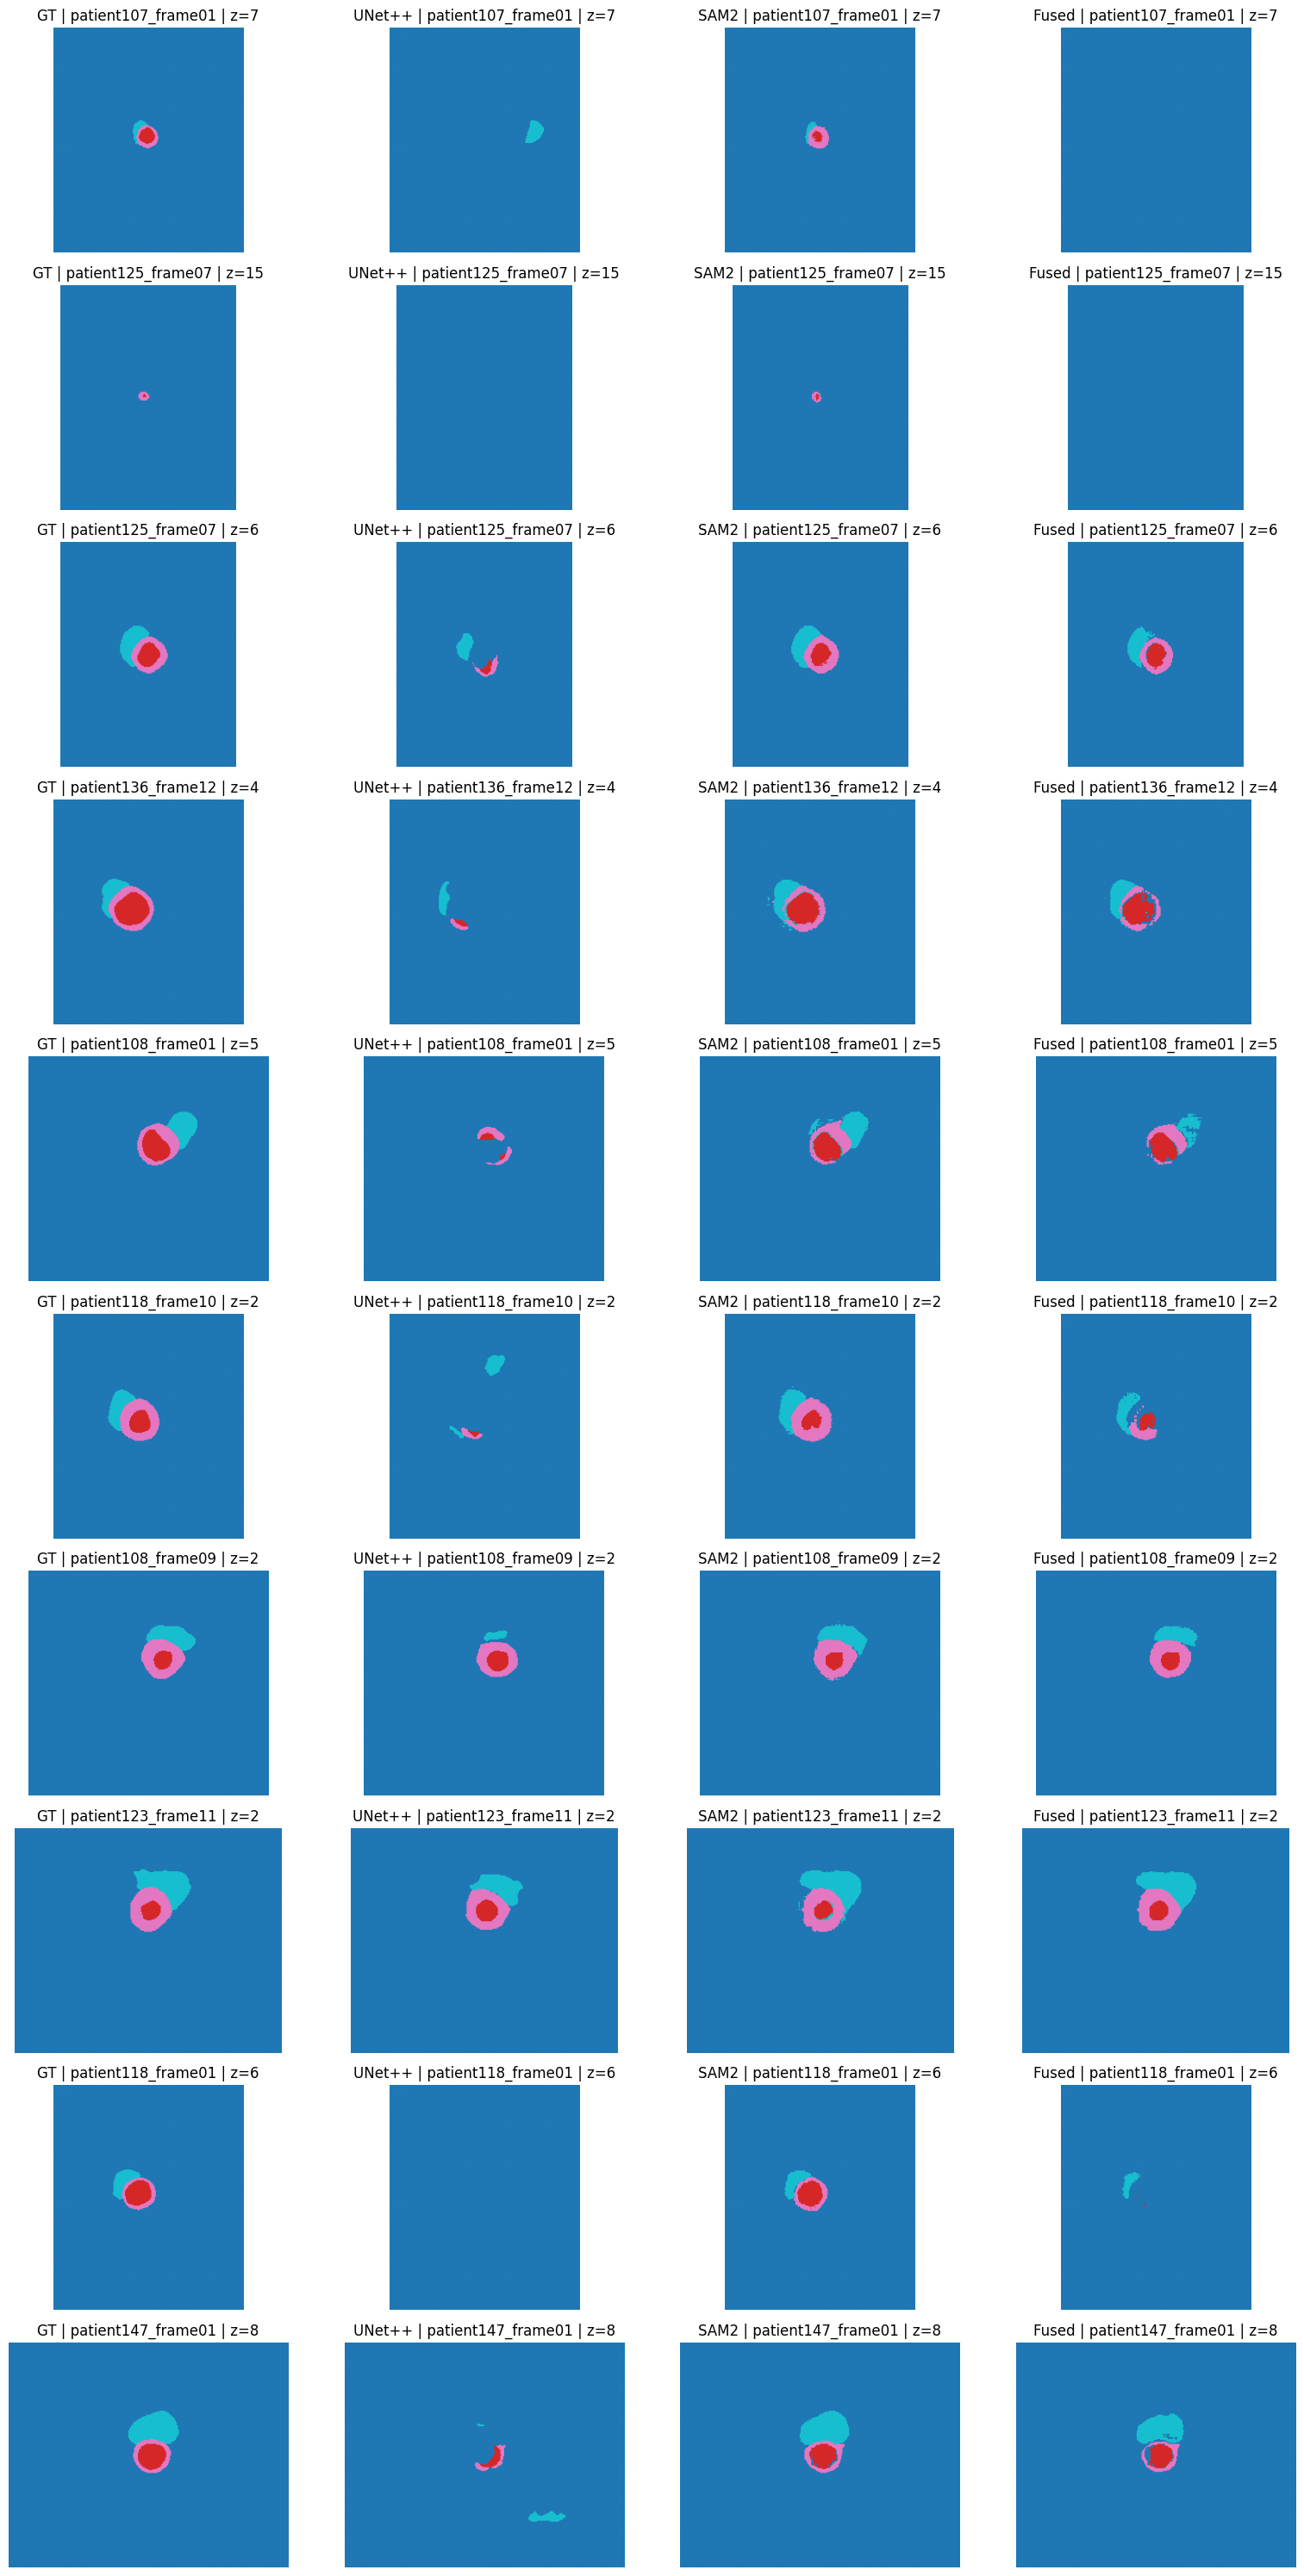

In [ ]:
# --- SIMPLE AVERAGING FUSION (SAM2 + UNet++ on ACDC, UNCALIBRATED, CLEAN & CORRECT) ---
import os
import numpy as np
import nibabel as nib
import cv2
import random
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
unetpp_dir = "/content/drive/MyDrive/Thesis-ontariotech/U-netpp/acdc_unetpp_soft_npz-suboptimal"
sam2_dir   = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/oracle_iou_main/new_acdc_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"

# ---------------- LABEL MAPPING ----------------
# Align SAM2 channels to UNet++/GT convention: [bg, LV, RV, MYO]
sam2_to_unetpp   = [0, 1, 3, 2]
# Map ACDC GT labels to this convention (ACDC: 0=bg,1=RV,2=MYO,3=LV -> target: 0=bg,1=LV,2=RV,3=MYO)
gt_to_pred_order = {0: 0, 1: 3, 2: 2, 3: 1}

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    """Compute per-class Dice/IoU for LV(1), RV(2), MYO(3) and macro."""
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou

def reorder_lv_rv_myo(arr):
    return [arr[0], arr[1], arr[2]]

# ---------------- MAIN ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(unetpp_dir) if f.endswith(".npz")]
all_cases.sort()

dice_all, iou_all = [], []

# Visualization reservoir
VIS_K = 10
vis_samples = []
seen = 0
rng = random.Random(38)

for case_id in all_cases:
    unetpp_path = os.path.join(unetpp_dir, f"{case_id}.npz")
    sam2_path   = os.path.join(sam2_dir,   f"{case_id}_sam2soft.npz")
    label_path  = os.path.join(label_dir,  f"{case_id}.nii.gz")

    if not all(os.path.exists(p) for p in [unetpp_path, sam2_path, label_path]):
        continue

    # --- Load predictions ---
    unetpp_raw = np.load(unetpp_path)["probabilities"]
    if unetpp_raw.ndim != 4:
        continue

    # Transpose if necessary to (C,H,W,D)
    if unetpp_raw.shape[1] != unetpp_raw.shape[2]:
        unetpp = np.transpose(unetpp_raw, (0, 3, 2, 1))
    else:
        unetpp = unetpp_raw

    sam2 = np.load(sam2_path)["probs"][sam2_to_unetpp, ...]

    # --- Load & map GT ---
    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)
    label = np.vectorize(gt_to_pred_order.get)(label)

    _, Hn, Wn, D_unet = unetpp.shape
    _, Hs, Ws, D_sam  = sam2.shape
    Hg, Wg, D_gt      = label.shape
    D = min(D_unet, D_sam, D_gt)

    fused_vol = np.zeros((Hg, Wg, D), dtype=np.uint8)
    valid_slices = []

    # --- Slice-wise averaging ---
    for z in range(D):
        gt_slice = label[..., z]
        if np.all(gt_slice == 0):
            continue  # skip blank GT
        valid_slices.append(z)

        unet_slice = np.moveaxis(unetpp[..., z], 0, -1)
        if (Hn, Wn) != (Hg, Wg):
            unet_slice = cv2.resize(unet_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        sam_slice = sam2[..., z].transpose(1, 2, 0)
        if (Hs, Ws) != (Hg, Wg):
            sam_slice = cv2.resize(sam_slice, (Wg, Hg), interpolation=cv2.INTER_LINEAR)

        # --- Pure averaging (one renorm only) ---
        fused_probs = 0.5 * (sam_slice + unet_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)

        fused_pred = np.argmax(fused_probs, axis=-1)
        unet_pred  = np.argmax(unet_slice, axis=-1)
        sam_pred   = np.argmax(sam_slice, axis=-1)
        fused_vol[..., z] = fused_pred

        # --- Visualization reservoir ---
        seen += 1
        if np.any(gt_slice > 0):
            if len(vis_samples) < VIS_K:
                vis_samples.append({
                    "case": case_id, "z": z,
                    "gt": gt_slice.copy(),
                    "unet": unet_pred.copy(),
                    "sam": sam_pred.copy(),
                    "fused": fused_pred.copy()
                })
            else:
                j = rng.randint(0, seen - 1)
                if j < VIS_K:
                    vis_samples[j] = {
                        "case": case_id, "z": z,
                        "gt": gt_slice.copy(),
                        "unet": unet_pred.copy(),
                        "sam": sam_pred.copy(),
                        "fused": fused_pred.copy()
                    }

    # --- Compute metrics only on valid slices ---
    if not valid_slices:
        continue
    d, j = compute_metrics(fused_vol[..., valid_slices], label[..., valid_slices])
    d_ord = reorder_lv_rv_myo(d)
    j_ord = reorder_lv_rv_myo(j)
    dice_all.append(d_ord + [float(np.mean(d))])
    iou_all.append(j_ord + [float(np.mean(j))])

# ---------------- AGGREGATE & PRINT ----------------
if len(dice_all) == 0:
    print("No valid cases found. Check your paths or NPZs.")
else:
    dice_all = np.array(dice_all)
    iou_all  = np.array(iou_all)

    mean_dice, std_dice = np.mean(dice_all, 0), np.std(dice_all, 0)
    mean_iou,  std_iou  = np.mean(iou_all,  0), np.std(iou_all,  0)

    labels = ["LV", "RV", "MYO", "Macro Avg"]
    print("\n=== FINAL SIMPLE AVERAGING FUSION RESULTS (SAM2 + UNet++, UNCALIBRATED) ===")
    for i, lab in enumerate(labels):
        print(f"{lab}: Dice = {mean_dice[i]:.4f} ± {std_dice[i]:.4f} | IoU = {mean_iou[i]:.4f} ± {std_iou[i]:.4f}")

# ---------------- VISUALIZATION ----------------
if len(vis_samples) > 0:
    n = len(vis_samples)
    fig, axes = plt.subplots(n, 4, figsize=(16, n*3))
    if n == 1:
        axes = np.expand_dims(axes, axis=0)
    for r, s in enumerate(vis_samples):
        panels = [("GT", s["gt"]), ("UNet++", s["unet"]), ("SAM2", s["sam"]), ("Fused", s["fused"])]
        for c, (title, img) in enumerate(panels):
            ax = axes[r, c]
            ax.imshow(img, cmap="tab10", vmin=0, vmax=3)
            ax.set_title(f"{title} | {s['case']} | z={s['z']}")
            ax.axis("off")
    plt.tight_layout()
    plt.show()
else:
    print("No slices collected for visualization (all GT slices were blank).")


###Medsam

##Run this
Medsam2+nnunet (in domain)

In [ ]:
# --- SIMPLE AVERAGING FUSION (nnU-Net + MedSAM2, MnM in-domain) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS (from your MedSAM2 + nnUNet DST code) ----------------
imagesTs_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/imagesTs"
nnunet_dir   = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_results/inference_output2"
medsam2_dir  = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/medsam2/logit_soft_npz"
label_dir    = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/mnmchallengefinetune/nnUNet_dataset/nnUNet_raw/Dataset114_MNMs/labelsTr"

output_csv = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/medsam2_nnunet_indomain.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

# ---------------- METRIC FUNCTIONS ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou, np.mean(dice), np.mean(iou)

# ---------------- FUSION + METRIC CALCULATION ----------------
all_cases = [f.replace("_0000.nii.gz", "") for f in os.listdir(imagesTs_dir) if f.endswith("_0000.nii.gz")]
all_cases.sort()

records = []

for case_id in all_cases:
    nn_path   = os.path.join(nnunet_dir,  f"{case_id}.npz")
    med_path  = os.path.join(medsam2_dir, f"{case_id}_medsam2soft.npz")
    label_path = os.path.join(label_dir,  f"{case_id}.nii.gz")

    if not (os.path.exists(nn_path) and os.path.exists(med_path) and os.path.exists(label_path)):
        print(f"[WARN] Missing file(s) for case {case_id}, skipping.")
        continue

    # ----- Load data -----
    # nnUNet: (C, D, W, H) -> (C, H, W, D)
    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C, H, W, D)

    # MedSAM2: (C, H_medsam, W_medsam, D)
    medsam2 = np.load(med_path)["probs"]

    label = np.array(nib.load(label_path).get_fdata(), dtype=np.uint8)

    C, H_nnunet, W_nnunet, D = nnunet.shape
    _, H_medsam, W_medsam, D_medsam = medsam2.shape

    assert D == D_medsam, f"Depth mismatch for case {case_id}: nnUNet D={D}, MedSAM2 D={D_medsam}"

    fused_vol = np.zeros((H_nnunet, W_nnunet, D), dtype=np.uint8)
    unet_pred = np.zeros_like(fused_vol)
    med_pred  = np.zeros_like(fused_vol)

    for z in range(D):
        # nn_slice: (H, W, C)
        nn_slice = np.moveaxis(nnunet[:, :, :, z], 0, -1)

        # med_slice: (H_medsam, W_medsam, C)
        med_slice = np.moveaxis(medsam2[:, :, :, z], 0, -1)

        # Resize MedSAM2 slice to nnUNet resolution
        med_resized = cv2.resize(med_slice, (W_nnunet, H_nnunet), interpolation=cv2.INTER_LINEAR)

        # Predictions from individual models
        unet_pred[..., z] = np.argmax(nn_slice, axis=-1)
        med_pred[..., z]  = np.argmax(med_resized, axis=-1)

        # -------- Simple averaging fusion --------
        # Both nn_slice and med_resized are (H, W, C) and already include background + 3 classes
        fused_probs = 0.5 * (nn_slice + med_resized)

        # Normalize to ensure probabilities sum to 1 (numerically safe)
        fused_probs_sum = np.sum(fused_probs, axis=-1, keepdims=True)
        fused_probs /= np.clip(fused_probs_sum, 1e-8, None)

        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # --- Compute metrics for nnUNet, MedSAM2, and Fused ---
    d_unet, j_unet, d_unet_macro, j_unet_macro = compute_metrics(unet_pred, label)
    d_med, j_med, d_med_macro, j_med_macro     = compute_metrics(med_pred, label)
    d_fused, j_fused, d_fused_macro, j_fused_macro = compute_metrics(fused_vol, label)

    # --- Record metrics ---
    records.append([
        case_id,
        *d_unet, *j_unet,
        *d_med, *j_med,
        *d_fused, *j_fused,
        d_unet_macro, j_unet_macro,
        d_med_macro, j_med_macro,
        d_fused_macro, j_fused_macro
    ])

# ---------------- CONVERT TO CSV ----------------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV", "unet_IoU_RV", "unet_IoU_Myo",
    "med_Dice_LV", "med_Dice_RV", "med_Dice_Myo",
    "med_IoU_LV", "med_IoU_RV", "med_IoU_Myo",
    "fused_Dice_LV", "fused_Dice_RV", "fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet", "Macro_IoU_UNet",
    "Macro_Dice_MedSAM2", "Macro_IoU_MedSAM2",
    "Macro_Dice_Fused", "Macro_IoU_Fused"
]

df = pd.DataFrame(records, columns=cols)

# --- Add summary rows ---
avg = df.mean(numeric_only=True)
std = df.std(numeric_only=True)
var = df.var(numeric_only=True)
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

avg_row      = pd.DataFrame([["Average"]    + avg.tolist()],      columns=df.columns)
std_row      = pd.DataFrame([["Std"]        + std.tolist()],      columns=df.columns)
var_row      = pd.DataFrame([["Var"]        + var.tolist()],      columns=df.columns)
mean_std_row = pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)

df = pd.concat([df, avg_row, std_row, var_row, mean_std_row], ignore_index=True)

# --- Save to CSV ---
df.to_csv(output_csv, index=False)
print(f"\n[OK] Metrics saved to {output_csv}")



[OK] Metrics saved to /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/medsam2_nnunet_indomain.csv


Medsam2+nnunet (cross domain)

In [ ]:
# --- SIMPLE AVERAGING FUSION (ACDC, MedSAM2 + nnU-Net, UNCALIBRATED) ---
import os
import numpy as np
import nibabel as nib
import cv2
import pandas as pd
from sklearn.metrics import f1_score, jaccard_score

# ---------------- PATHS ----------------
nnunet_dir = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/nnUNet_results/inference_output_acdc"
medsam2_dir = "/content/drive/MyDrive/Thesis-ontariotech/SAM2-model/medsam2/ACDC_logit_soft_npz"
label_dir  = "/content/drive/MyDrive/Thesis-ontariotech/Dataset/ACDC_nnunet/nnUNet_raw/Dataset114_ACDC/labelsTr"

output_csv = "/content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/medsam2_nnunet_crossdomain.csv"
os.makedirs(os.path.dirname(output_csv), exist_ok=True)

# ---------------- LABEL MAPPING ----------------
# Reuse mapping from your MedSAM2+nnUNet DST fusion
medsam2_to_nnunet = [0, 1, 3, 2]           # reorder MedSAM2 classes to match nnUNet / GT
gt_to_pred_order  = {0: 0, 1: 3, 2: 2, 3: 1}  # remap GT labels to match prediction convention

# ---------------- METRIC FUNCTION ----------------
def compute_metrics(pred, gt):
    pred_f, gt_f = pred.flatten(), gt.flatten()
    dice = f1_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    iou  = jaccard_score(gt_f, pred_f, average=None, labels=[1, 2, 3])
    return dice, iou, np.mean(dice), np.mean(iou)

# ---------------- MAIN LOOP ----------------
all_cases = [f.replace(".npz", "") for f in os.listdir(nnunet_dir) if f.endswith(".npz")]
all_cases.sort()

records = []

for cid in all_cases:
    nn_path  = os.path.join(nnunet_dir, f"{cid}.npz")
    med_path = os.path.join(medsam2_dir, f"{cid}_medsam2soft.npz")
    lab_path = os.path.join(label_dir,  f"{cid}.nii.gz")

    if not all(os.path.exists(p) for p in [nn_path, med_path, lab_path]):
        print(f"[WARN] Missing file(s) for case {cid}, skipping.")
        continue

    # --- Load data ---
    # nnUNet: (C, D, W, H) -> (C, H, W, D)
    nnunet = np.load(nn_path)["probabilities"]
    nnunet = np.transpose(nnunet, (0, 3, 2, 1))  # (C, H, W, D)

    # MedSAM2: (C, Hm, Wm, D), remap classes to nnUNet order
    med = np.load(med_path)["probs"][medsam2_to_nnunet, ...]  # (4, Hm, Wm, D)

    # Ground truth: remap labels to prediction order
    label = np.array(nib.load(lab_path).get_fdata(), dtype=np.uint8)
    label = np.vectorize(gt_to_pred_order.get)(label)

    C, H, W, D = nnunet.shape
    _, Hm, Wm, Dm = med.shape
    assert D == Dm, f"[ERR] Depth mismatch for case {cid}: nnUNet D={D}, MedSAM2 D={Dm}"

    fused_vol = np.zeros((H, W, D), dtype=np.uint8)
    unet_pred = np.zeros_like(fused_vol)
    med_pred  = np.zeros_like(fused_vol)

    # --- Slice-wise fusion ---
    for z in range(D):
        # Skip slices with completely empty GT (all background)
        if np.all(label[..., z] == 0):
            continue

        # nnUNet slice: (H, W, 4)
        nn_slice = np.moveaxis(nnunet[..., z], 0, -1)

        # MedSAM2 slice: (Hm, Wm, 4) -> resize to (H, W)
        med_slice = med[..., z].transpose(1, 2, 0)
        med_resized = cv2.resize(med_slice, (W, H), interpolation=cv2.INTER_LINEAR)

        # Per-model predictions
        unet_pred[..., z] = np.argmax(nn_slice, axis=-1)
        med_pred[..., z]  = np.argmax(med_resized, axis=-1)

        # ------- Simple averaging fusion -------
        fused_probs = 0.5 * (med_resized + nn_slice)
        fused_probs /= np.clip(np.sum(fused_probs, axis=-1, keepdims=True), 1e-8, None)
        fused_vol[..., z] = np.argmax(fused_probs, axis=-1)

    # --- Compute metrics over full volume ---
    d_unet, j_unet, d_unet_macro, j_unet_macro = compute_metrics(unet_pred, label)
    d_med,  j_med,  d_med_macro,  j_med_macro  = compute_metrics(med_pred, label)
    d_fused, j_fused, d_fused_macro, j_fused_macro = compute_metrics(fused_vol, label)

    # --- Record row ---
    records.append([
        cid,
        *d_unet, *j_unet,
        *d_med, *j_med,
        *d_fused, *j_fused,
        d_unet_macro, j_unet_macro,
        d_med_macro, j_med_macro,
        d_fused_macro, j_fused_macro
    ])

# ---------------- SAVE RESULTS TO CSV ----------------
cols = [
    "Case",
    "unet_Dice_LV", "unet_Dice_RV", "unet_Dice_Myo",
    "unet_IoU_LV", "unet_IoU_RV", "unet_IoU_Myo",
    "med_Dice_LV", "med_Dice_RV", "med_Dice_Myo",
    "med_IoU_LV", "med_IoU_RV", "med_IoU_Myo",
    "fused_Dice_LV", "fused_Dice_RV", "fused_Dice_Myo",
    "fused_IoU_LV", "fused_IoU_RV", "fused_IoU_Myo",
    "Macro_Dice_UNet", "Macro_IoU_UNet",
    "Macro_Dice_MedSAM2", "Macro_IoU_MedSAM2",
    "Macro_Dice_Fused", "Macro_IoU_Fused"
]

df = pd.DataFrame(records, columns=cols)

# --- Summary rows ---
avg = df.mean(numeric_only=True)
std = df.std(numeric_only=True)
var = df.var(numeric_only=True)
mean_std = avg.round(3).astype(str) + " ± " + std.round(3).astype(str)

avg_row      = pd.DataFrame([["Average"]    + avg.tolist()],      columns=df.columns)
std_row      = pd.DataFrame([["Std"]        + std.tolist()],      columns=df.columns)
var_row      = pd.DataFrame([["Var"]        + var.tolist()],      columns=df.columns)
mean_std_row = pd.DataFrame([["Mean ± Std"] + mean_std.tolist()], columns=df.columns)

df = pd.concat([df, avg_row, std_row, var_row, mean_std_row], ignore_index=True)

df.to_csv(output_csv, index=False)
print(f"\n[OK] Metrics saved to {output_csv}")



[OK] Metrics saved to /content/drive/MyDrive/Thesis-ontariotech/ablations/simple_averaging/medsam2_nnunet_crossdomain.csv
